### Run this notebook online

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-F9AB00?logo=googlecolab&logoColor=F9AB00)](https://colab.research.google.com/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/VAE%20U-DiT.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2Fhosein-fanai%2FContinual-Learning-with-Diffusion-Vision-Transformers%2Fblob%2Fmain%2Fnotebooks%2FVAE%2520U-DiT.ipynb)
[![Launch Binder](https://img.shields.io/badge/launch-binder-F5793A?logo=jupyter&logoColor=white)](https://mybinder.org/v2/gh/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/main?urlpath=lab%2Ftree%2Fnotebooks%2FVAE%20U-DiT.ipynb)

- **Google Colab:** open the notebook, select a GPU for training under **Runtime > Change runtime type**, then choose **Run all**.
- **Kaggle:** sign in and import the notebook, enable **Internet**, select a **GPU** accelerator for training, then **Run all**.
- **Binder:** opens a temporary CPU JupyterLab session. Use it to inspect the notebook or run small checks; full training needs more resources.
- **[Studio Lab](https://studiolab.sagemaker.aws/import/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/VAE%20U-DiT.ipynb) (existing accounts only):** start a runtime, copy the notebook to your project, select a Python **3.11–3.13** kernel, and set `RUNTIME = "studiolab"` in the first code cell before **Run all**. For CPU, also set `CUDA = False`.

The **first code cell** finds or downloads the repository and prepares TensorFlow **2.20** / Keras **3.11.2** before project imports. If setup requests a restart, restart the kernel and run all again. For another hosted Jupyter service, set `RUNTIME = "hosted"` (`CUDA = False` for CPU or compatible provider-managed CUDA). Locally, select the project TensorFlow kernel.

Launch links open the published GitHub `main` version; publish this notebook and its setup files together before using them. For a notebook that has not been published, upload its `.ipynb` file to Colab or Kaggle instead. GPU availability depends on the provider. Save checkpoints and results before a temporary session ends.

See the [hosted runtime guide](https://github.com/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/thesis/README.md#hosted-runtimes) for setup and import details.


In [ ]:
# Shared setup: use the local initializer when available, otherwise download it.
from pathlib import Path
from urllib.request import urlopen


CHECKOUT_NAME = "Continual-Learning-with-Diffusion-Vision-Transformers"
REPOSITORY = f"https://github.com/hosein-fanai/{CHECKOUT_NAME}.git"
REVISION = "main"
RUNTIME = "auto"  # Use "hosted" for another online service, or "local" to verify only.
CUDA = None  # False: CPU or managed CUDA; True: retain CUDA pip dependencies.

_locations = (Path.cwd(), *Path.cwd().parents, Path.cwd() / CHECKOUT_NAME,
              Path("/kaggle/working") / CHECKOUT_NAME, Path("/content") / CHECKOUT_NAME)
_initializer = next((path / "notebooks" / "init.py" for path in _locations
                     if (path / "notebooks" / "init.py").is_file()), None)
_url = f"https://raw.githubusercontent.com/hosein-fanai/{CHECKOUT_NAME}/{REVISION}/notebooks/init.py"
_setup = {"__name__": "notebook_setup", "__file__": str(_initializer or _url)}
with (_initializer.open("rb") if _initializer else urlopen(_url, timeout=30)) as _file:
    exec(compile(_file.read(), _setup["__file__"], "exec"), _setup)
ROOT, RUNTIME_PACKAGES = _setup["prepare_notebook"](
    checkout_name=CHECKOUT_NAME, repository=REPOSITORY, revision=REVISION,
    runtime=RUNTIME, cuda=CUDA,
)


In [ ]:
import init

In [2]:
epochs = 100

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Trailing image dimensions
            are preserved; supply the channel dimension required by the model.
        y (np.ndarray): Labels with the same leading length as x. Values and label shape
            are preserved.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    # x = x[..., None]

    dataset = tf.data.Dataset.from_tensor_slices((x, y))

    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)

    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

In [4]:
from tensorflow.keras import datasets, layers

import numpy as np


(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = np.expand_dims(x_train, -1)
x_train = layers.ZeroPadding2D((2, 2))(x_train).numpy()

x_test = np.expand_dims(x_test, -1)
x_test = layers.ZeroPadding2D((2, 2))(x_test).numpy()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

In [5]:
from diffusion.models.wrapper.diffusion_model import DiffusionModel
from diffusion.models.transformer.diffusion_transformer import DiffusionTransformer


vit = DiffusionTransformer(
    image_size=32, 
    use_cfg=False, 
    dim_forced=False, 
    depth=16, 
    connection_ids_dict={8: (3,), 10: (1,), 12: (7,)}, 
    cross_attention_ids_dict={14: (9,), 16: (11,)}, 
    cross_attention_kwargs={
        "use_layer_norm": True, 
        "ln_no_adaptation": False
    }, 
    vit_block_ids=[1, 3, 5, 12, 14, 16], 
    use_decoder_ids=[14, 16], 
    vit_block_mlp_output_dims={1: 32, 3: 64, 5: 64, 12: 64, 14: 32, 16: 32}, 
    downsample_ids=[2, 4], 
    downsample_kwargs={
        "pos_embed_type": "2d_sincos", 
    }, 
    upsample_ids=[13, 15], 
    upsample_kwargs={
        "pos_embed_type": "2d_sincos", 
        "scaling_method": "interpolate", 
        "scaling_interpolation_method": "bilinear"
    }, 
    reshaper_ids_dict={
        6: "flatten", 7: "unflatten", 
        8: "flatten", 9: "unflatten", 
        10: "flatten", 11: "unflatten"
    }, 
    reshaper_kwargs={
        "add_kl": True, 
        "latent_dim_ratio": [1 / 32, 1 / 128, 1 / 256]
    }
)
model = DiffusionModel(
    network=vit, 
    swap_noise_image=True, 
    kl_loss_coef=0.01, 
    modify_first_t=True, 
    train_noisified_max_timesteps=0, 
    test_noisified_max_timesteps=0
)

vit.summary()

Model: "diffusion_transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 depth_0_patch_embedder (Pat  (None, 256, 32)          160       
 chEmbedding)                                                    
                                                                 
 depth_0_time_embedder (Cond  (None, 32)               32000     
 itionEmbedding)                                                 
                                                                 
 depth_0_label_embedder (Con  (None, 32)               320       
 ditionEmbedding)                                                
                                                                 
 depth_0_time_label_merger (  (None, 32)               0         
 Add)                                                            
                                                                 
 depth_1_encoder_block (Visi  (None, 256, 32)

In [6]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, 
    decay_steps=epochs * len(trainset), 
)

model.compile(
    optimizer=optimizers.Adam(
        lr_schedule, 
        # clipnorm=1., 
        global_clipnorm=1.
    ), 
    loss="mse", 
    # run_eagerly=True
)

In [ ]:
from tensorflow.keras import callbacks

from diffusion import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(), 
    ImageGenerator()
]

Epoch 1/100
468/468 [==============================] - 71s 119ms/step - loss: 0.2679 - noise_loss: 0.2068 - kl_loss: 6.1117 - val_loss: 1.1221 - val_noise_loss: 0.5747 - val_image_loss: 0.5747 - val_kl_loss: 54.7430 - learning_rate: 9.9975e-04


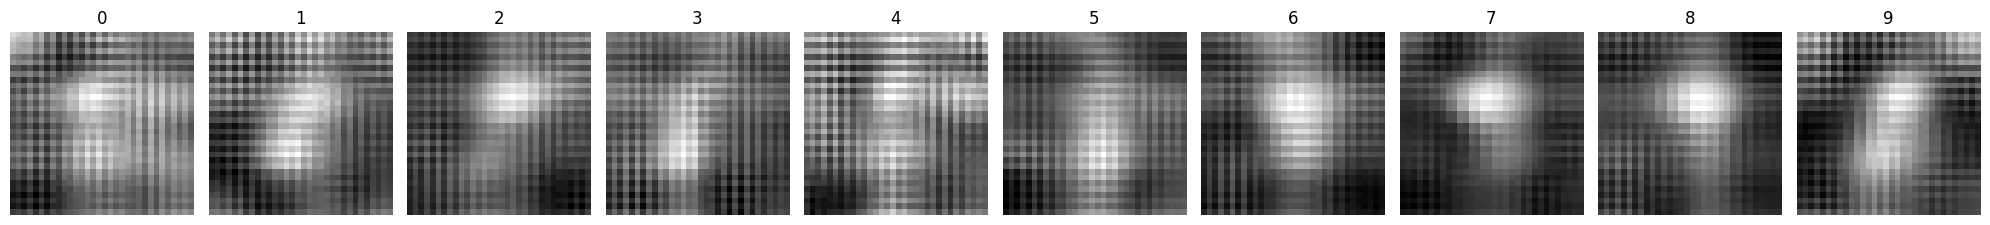

Epoch 2/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1571 - noise_loss: 0.1439 - kl_loss: 1.3225 - val_loss: 0.5049 - val_noise_loss: 0.3449 - val_image_loss: 0.3449 - val_kl_loss: 16.0017 - learning_rate: 9.9901e-04


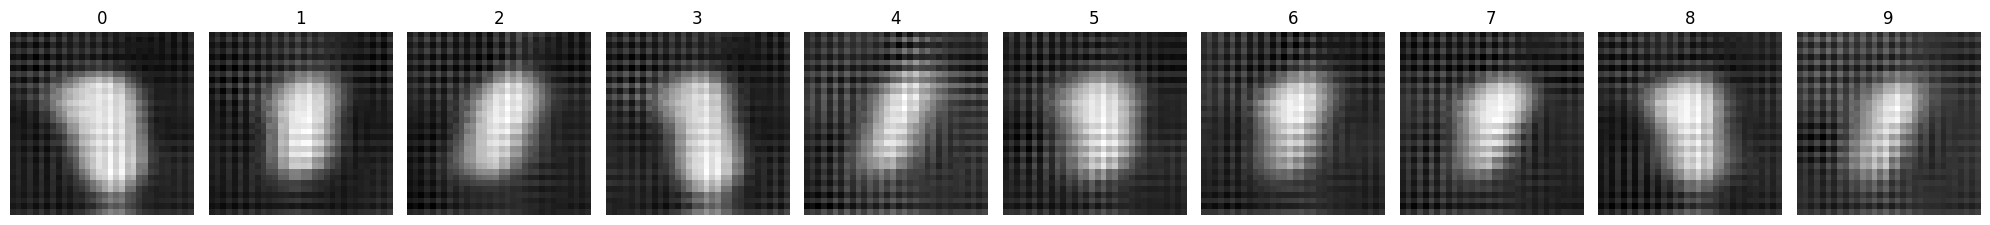

Epoch 3/100
468/468 [==============================] - 53s 112ms/step - loss: 0.1465 - noise_loss: 0.1279 - kl_loss: 1.8601 - val_loss: 0.2989 - val_noise_loss: 0.2453 - val_image_loss: 0.2453 - val_kl_loss: 5.3539 - learning_rate: 9.9778e-04


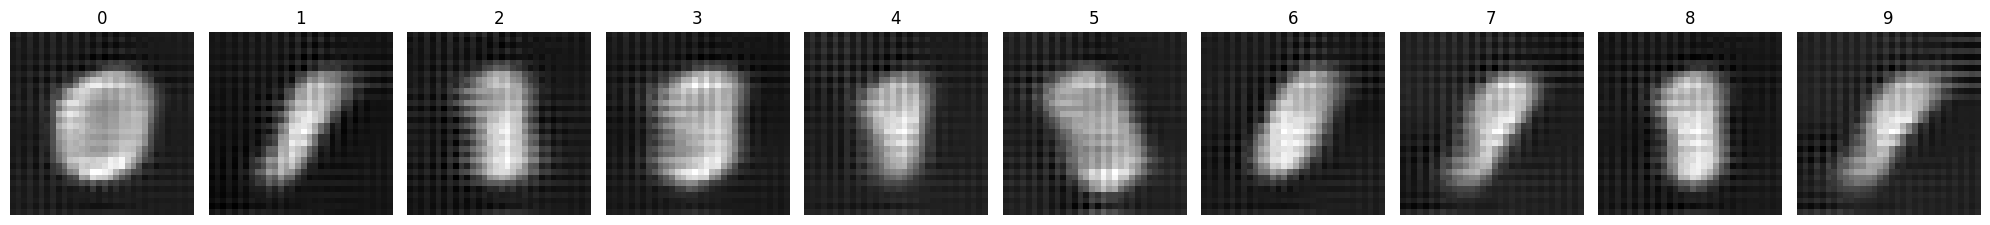

Epoch 4/100
468/468 [==============================] - 52s 112ms/step - loss: 0.1426 - noise_loss: 0.1219 - kl_loss: 2.0791 - val_loss: 0.2141 - val_noise_loss: 0.1896 - val_image_loss: 0.1896 - val_kl_loss: 2.4557 - learning_rate: 9.9606e-04


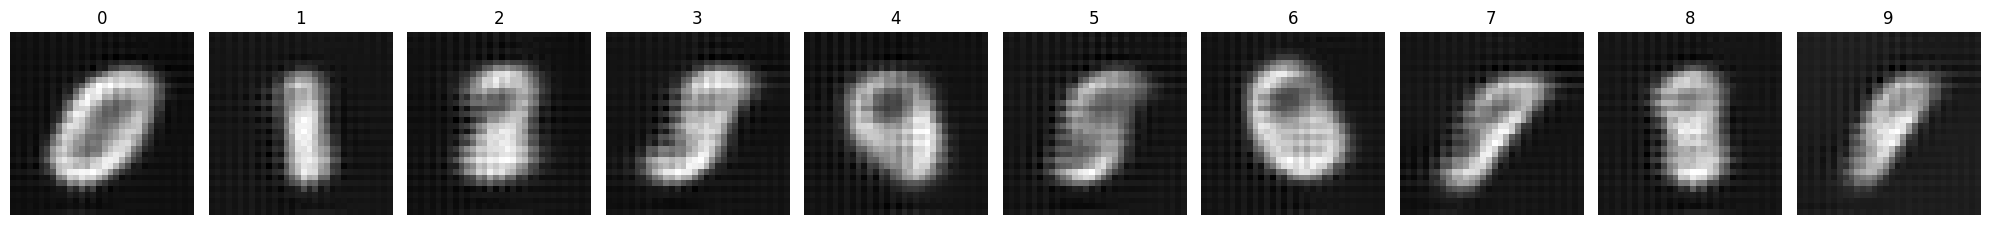

Epoch 5/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1407 - noise_loss: 0.1179 - kl_loss: 2.2729 - val_loss: 0.1739 - val_noise_loss: 0.1554 - val_image_loss: 0.1554 - val_kl_loss: 1.8509 - learning_rate: 9.9384e-04


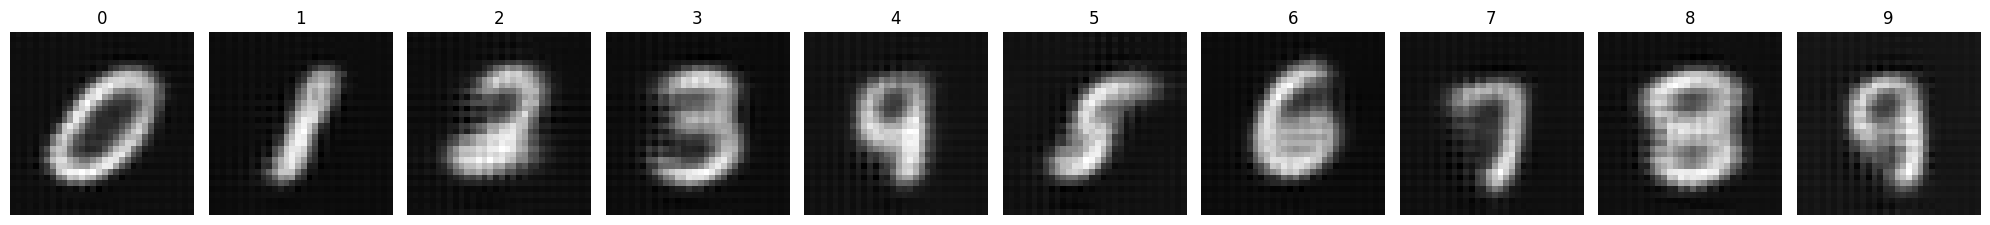

Epoch 6/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1387 - noise_loss: 0.1148 - kl_loss: 2.3893 - val_loss: 0.1537 - val_noise_loss: 0.1350 - val_image_loss: 0.1350 - val_kl_loss: 1.8668 - learning_rate: 9.9114e-04


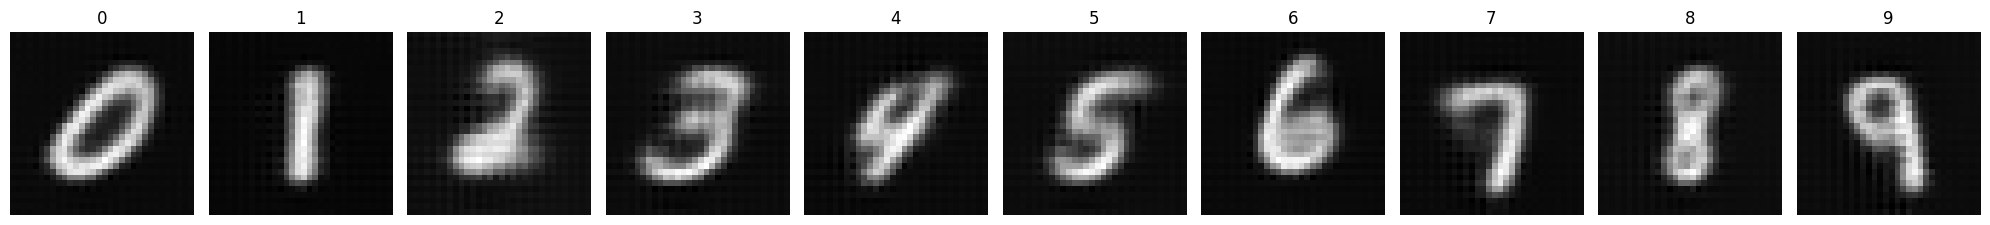

Epoch 7/100
468/468 [==============================] - 53s 112ms/step - loss: 0.1373 - noise_loss: 0.1118 - kl_loss: 2.5557 - val_loss: 0.1428 - val_noise_loss: 0.1223 - val_image_loss: 0.1223 - val_kl_loss: 2.0506 - learning_rate: 9.8796e-04


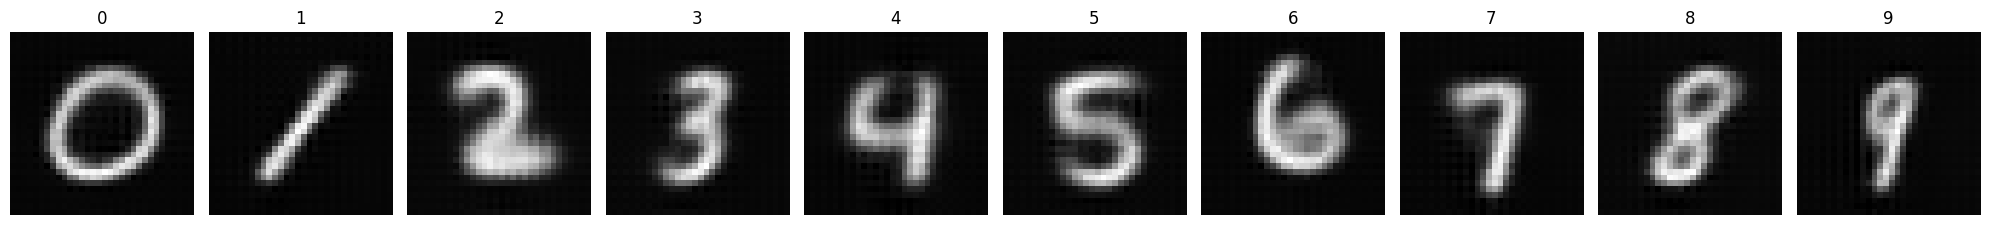

Epoch 8/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1356 - noise_loss: 0.1080 - kl_loss: 2.7548 - val_loss: 0.1374 - val_noise_loss: 0.1148 - val_image_loss: 0.1148 - val_kl_loss: 2.2661 - learning_rate: 9.8429e-04


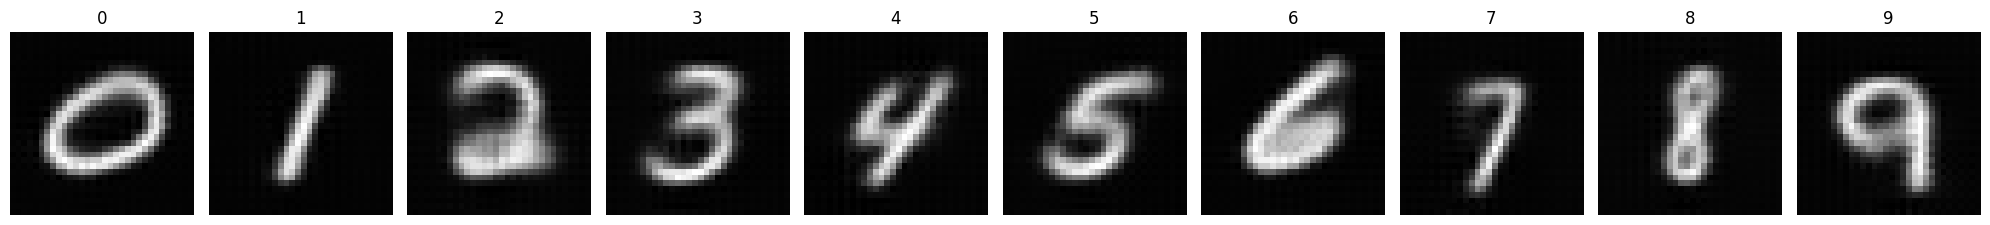

Epoch 9/100
468/468 [==============================] - 53s 112ms/step - loss: 0.1342 - noise_loss: 0.1054 - kl_loss: 2.8797 - val_loss: 0.1342 - val_noise_loss: 0.1096 - val_image_loss: 0.1096 - val_kl_loss: 2.4588 - learning_rate: 9.8015e-04


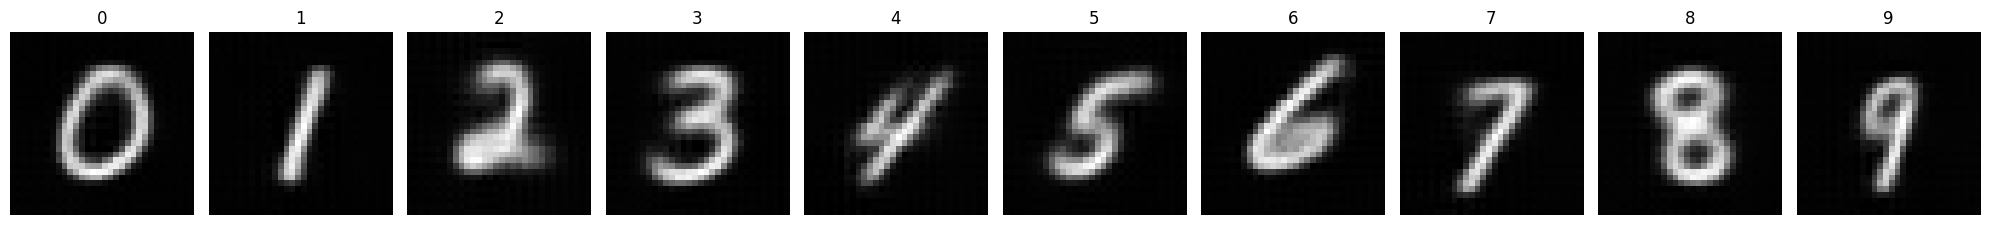

Epoch 10/100
468/468 [==============================] - 52s 111ms/step - loss: 0.1336 - noise_loss: 0.1040 - kl_loss: 2.9551 - val_loss: 0.1319 - val_noise_loss: 0.1058 - val_image_loss: 0.1058 - val_kl_loss: 2.6092 - learning_rate: 9.7553e-04


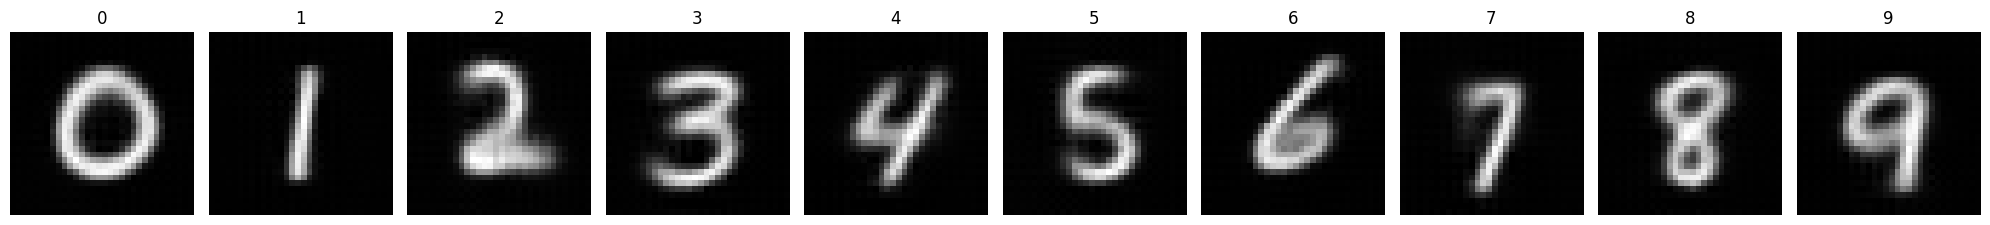

Epoch 11/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1329 - noise_loss: 0.1026 - kl_loss: 3.0264 - val_loss: 0.1307 - val_noise_loss: 0.1034 - val_image_loss: 0.1034 - val_kl_loss: 2.7325 - learning_rate: 9.7044e-04


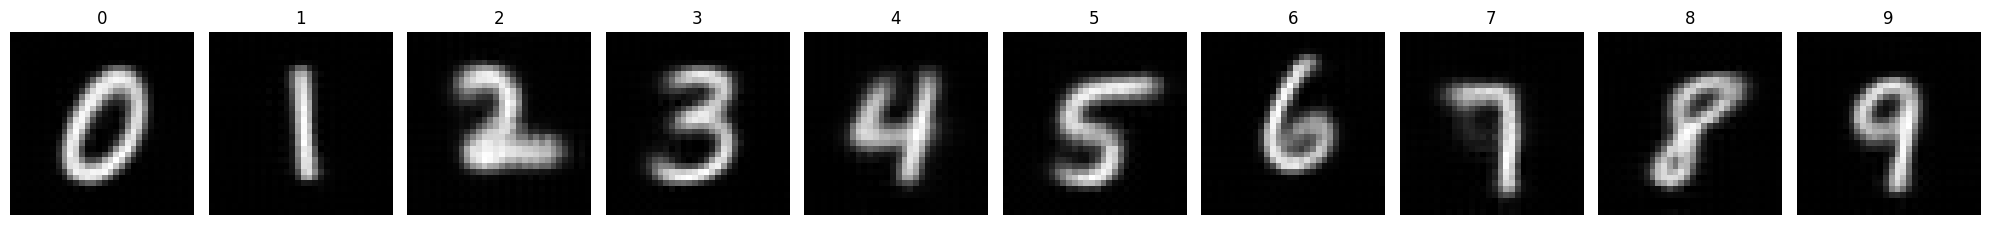

Epoch 12/100
468/468 [==============================] - 52s 112ms/step - loss: 0.1324 - noise_loss: 0.1017 - kl_loss: 3.0717 - val_loss: 0.1299 - val_noise_loss: 0.1016 - val_image_loss: 0.1016 - val_kl_loss: 2.8296 - learning_rate: 9.6489e-04


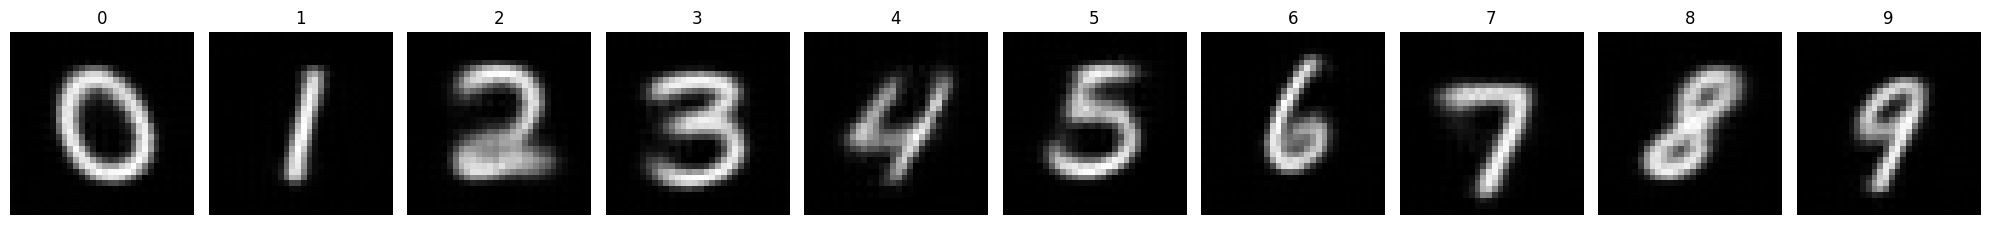

Epoch 13/100
468/468 [==============================] - 52s 111ms/step - loss: 0.1319 - noise_loss: 0.1007 - kl_loss: 3.1153 - val_loss: 0.1291 - val_noise_loss: 0.1000 - val_image_loss: 0.1000 - val_kl_loss: 2.9098 - learning_rate: 9.5888e-04


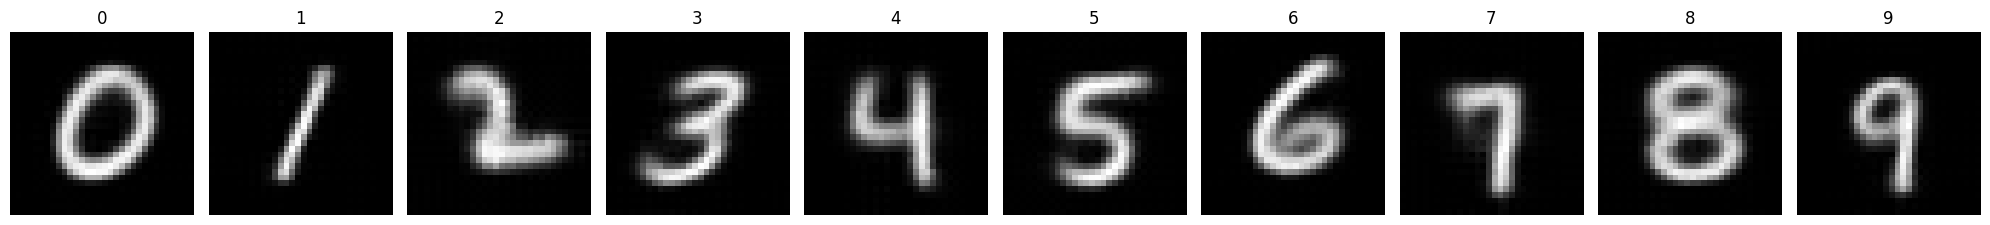

Epoch 14/100
468/468 [==============================] - 53s 112ms/step - loss: 0.1313 - noise_loss: 0.0999 - kl_loss: 3.1493 - val_loss: 0.1282 - val_noise_loss: 0.0984 - val_image_loss: 0.0984 - val_kl_loss: 2.9783 - learning_rate: 9.5241e-04


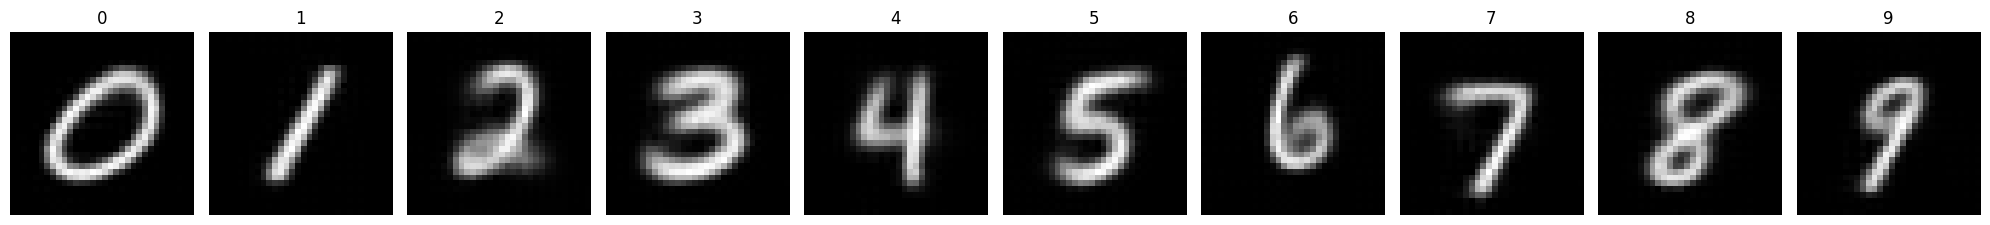

Epoch 15/100
468/468 [==============================] - 52s 112ms/step - loss: 0.1312 - noise_loss: 0.0993 - kl_loss: 3.1900 - val_loss: 0.1281 - val_noise_loss: 0.0977 - val_image_loss: 0.0977 - val_kl_loss: 3.0367 - learning_rate: 9.4550e-04


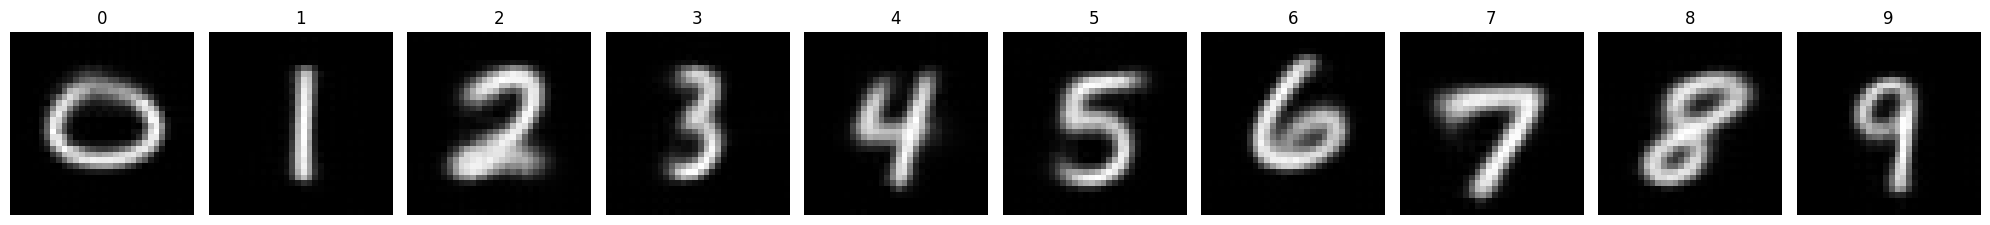

Epoch 16/100
468/468 [==============================] - 52s 112ms/step - loss: 0.1308 - noise_loss: 0.0987 - kl_loss: 3.2038 - val_loss: 0.1277 - val_noise_loss: 0.0969 - val_image_loss: 0.0969 - val_kl_loss: 3.0769 - learning_rate: 9.3815e-04


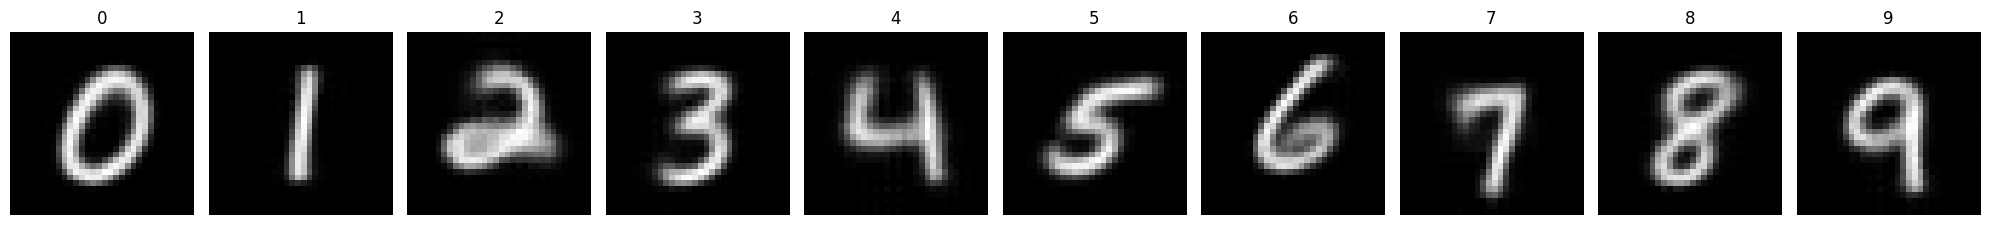

Epoch 17/100
468/468 [==============================] - 53s 112ms/step - loss: 0.1304 - noise_loss: 0.0981 - kl_loss: 3.2338 - val_loss: 0.1271 - val_noise_loss: 0.0959 - val_image_loss: 0.0959 - val_kl_loss: 3.1148 - learning_rate: 9.3037e-04


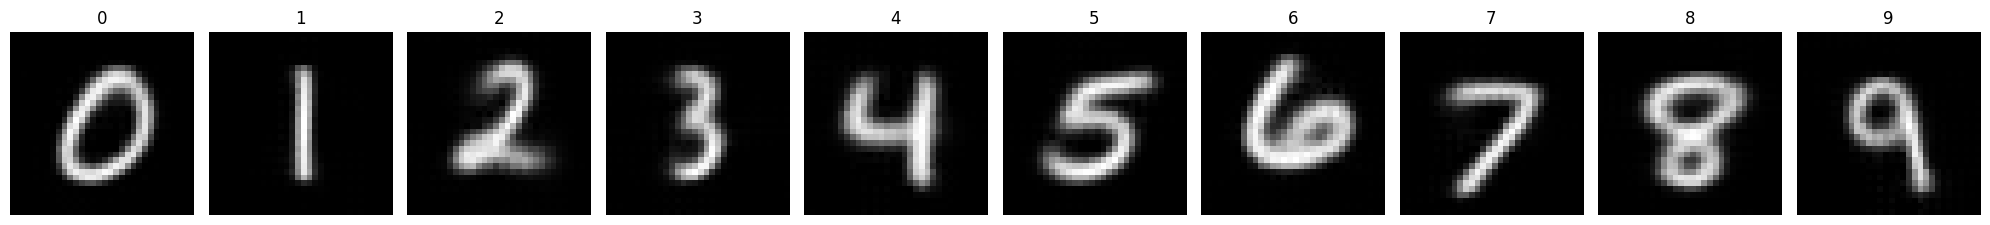

Epoch 18/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1303 - noise_loss: 0.0978 - kl_loss: 3.2472 - val_loss: 0.1271 - val_noise_loss: 0.0956 - val_image_loss: 0.0956 - val_kl_loss: 3.1471 - learning_rate: 9.2216e-04


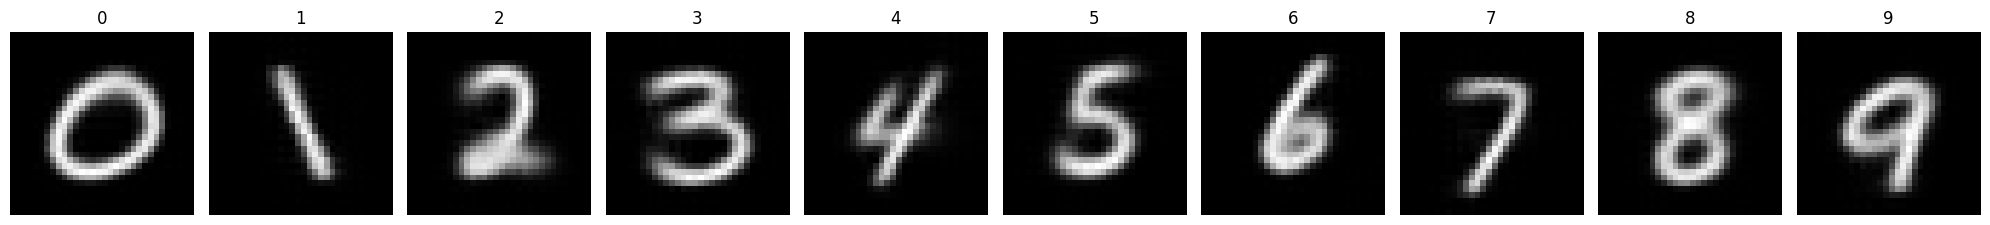

Epoch 19/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1300 - noise_loss: 0.0972 - kl_loss: 3.2775 - val_loss: 0.1266 - val_noise_loss: 0.0949 - val_image_loss: 0.0949 - val_kl_loss: 3.1775 - learning_rate: 9.1354e-04


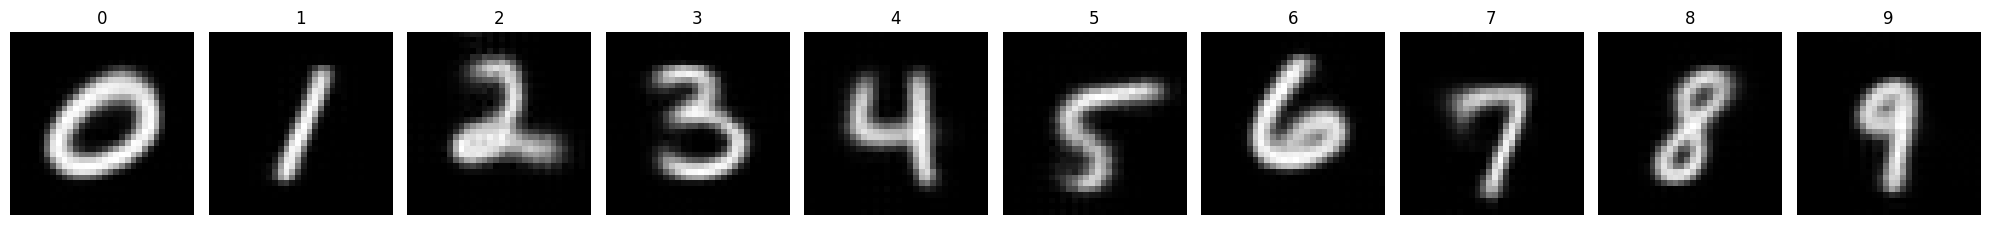

Epoch 20/100
468/468 [==============================] - 52s 112ms/step - loss: 0.1297 - noise_loss: 0.0967 - kl_loss: 3.3016 - val_loss: 0.1266 - val_noise_loss: 0.0946 - val_image_loss: 0.0946 - val_kl_loss: 3.2058 - learning_rate: 9.0451e-04


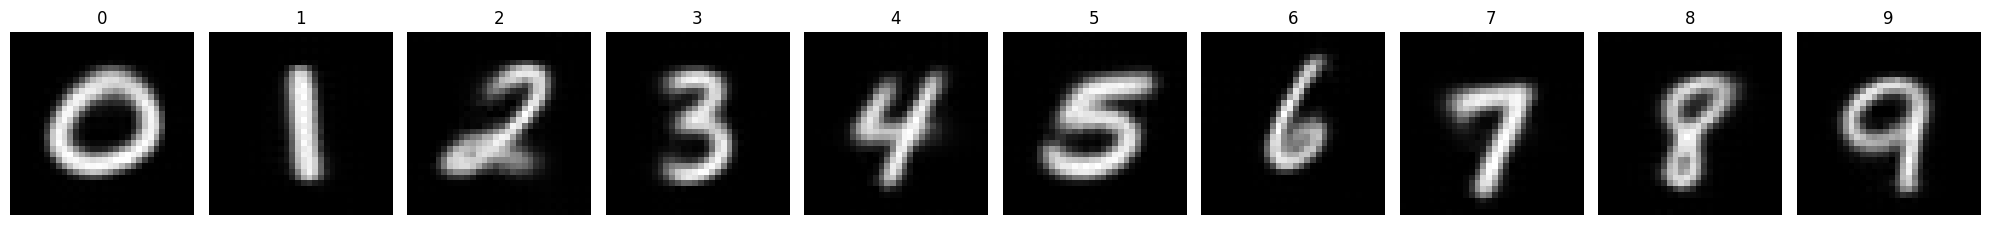

Epoch 21/100
468/468 [==============================] - 52s 112ms/step - loss: 0.1296 - noise_loss: 0.0963 - kl_loss: 3.3336 - val_loss: 0.1264 - val_noise_loss: 0.0940 - val_image_loss: 0.0940 - val_kl_loss: 3.2373 - learning_rate: 8.9508e-04


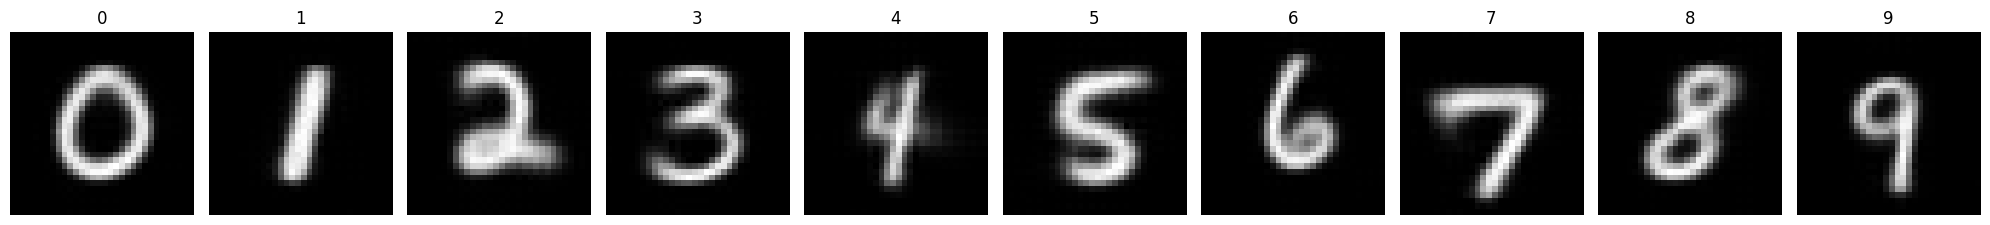

Epoch 22/100
468/468 [==============================] - 53s 112ms/step - loss: 0.1293 - noise_loss: 0.0958 - kl_loss: 3.3548 - val_loss: 0.1260 - val_noise_loss: 0.0934 - val_image_loss: 0.0934 - val_kl_loss: 3.2625 - learning_rate: 8.8526e-04


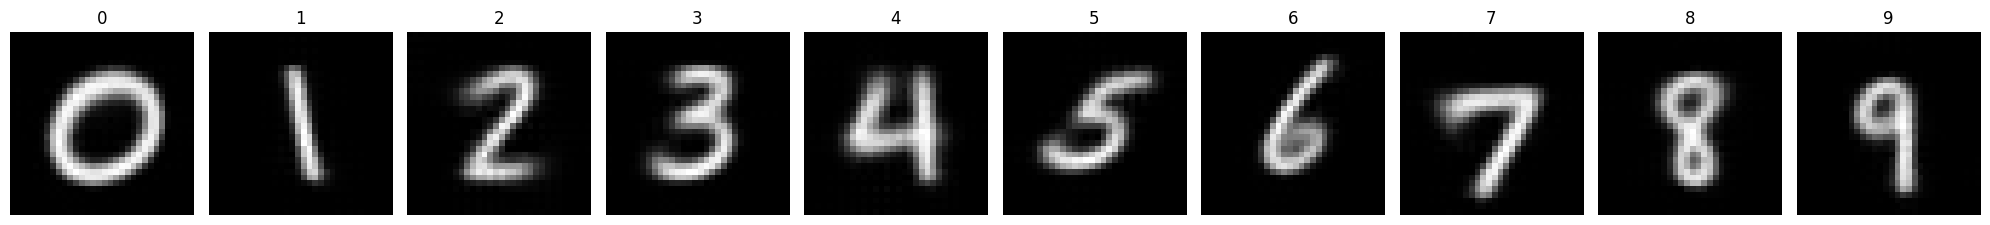

Epoch 23/100
468/468 [==============================] - 52s 112ms/step - loss: 0.1290 - noise_loss: 0.0952 - kl_loss: 3.3794 - val_loss: 0.1259 - val_noise_loss: 0.0930 - val_image_loss: 0.0930 - val_kl_loss: 3.2878 - learning_rate: 8.7506e-04


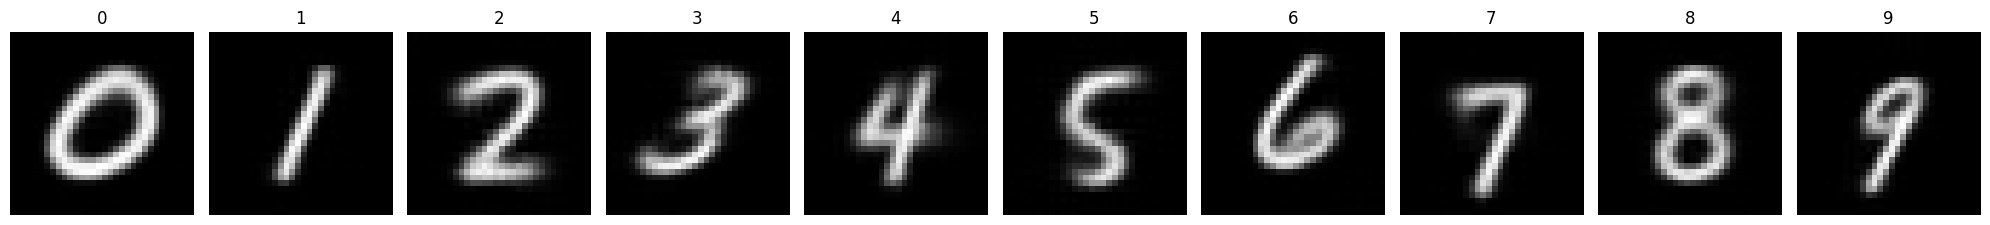

Epoch 24/100
468/468 [==============================] - 53s 112ms/step - loss: 0.1288 - noise_loss: 0.0950 - kl_loss: 3.3827 - val_loss: 0.1258 - val_noise_loss: 0.0927 - val_image_loss: 0.0927 - val_kl_loss: 3.3079 - learning_rate: 8.6448e-04


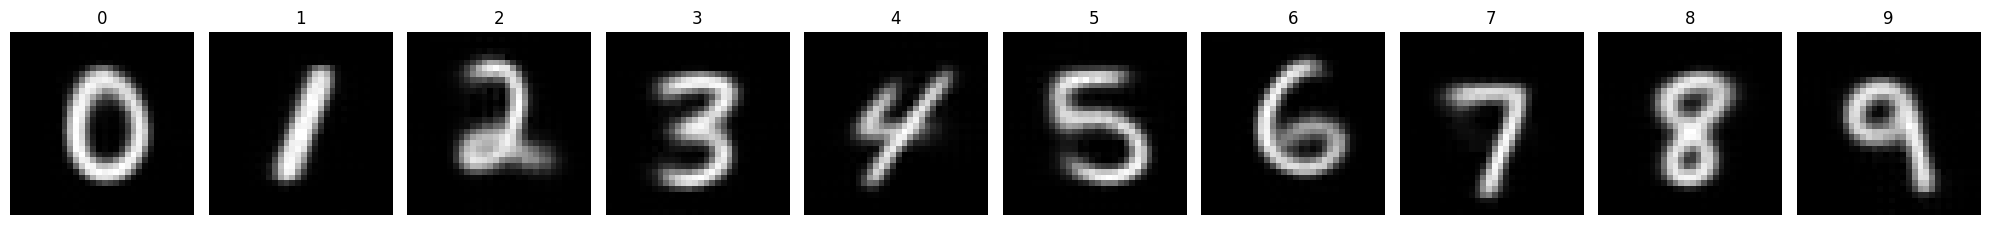

Epoch 25/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1285 - noise_loss: 0.0942 - kl_loss: 3.4251 - val_loss: 0.1258 - val_noise_loss: 0.0925 - val_image_loss: 0.0925 - val_kl_loss: 3.3349 - learning_rate: 8.5355e-04


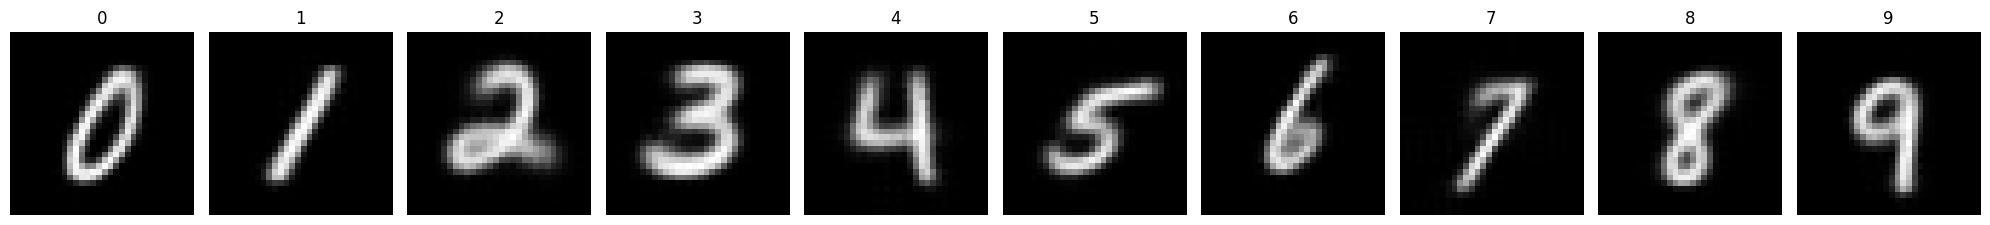

Epoch 26/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1285 - noise_loss: 0.0941 - kl_loss: 3.4400 - val_loss: 0.1256 - val_noise_loss: 0.0920 - val_image_loss: 0.0920 - val_kl_loss: 3.3576 - learning_rate: 8.4227e-04


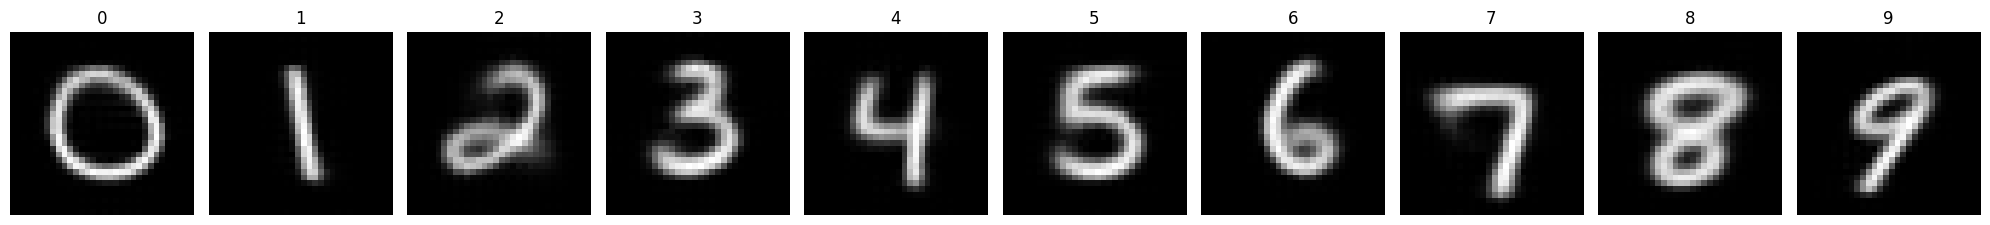

Epoch 27/100
468/468 [==============================] - 52s 111ms/step - loss: 0.1282 - noise_loss: 0.0936 - kl_loss: 3.4653 - val_loss: 0.1252 - val_noise_loss: 0.0914 - val_image_loss: 0.0914 - val_kl_loss: 3.3831 - learning_rate: 8.3066e-04


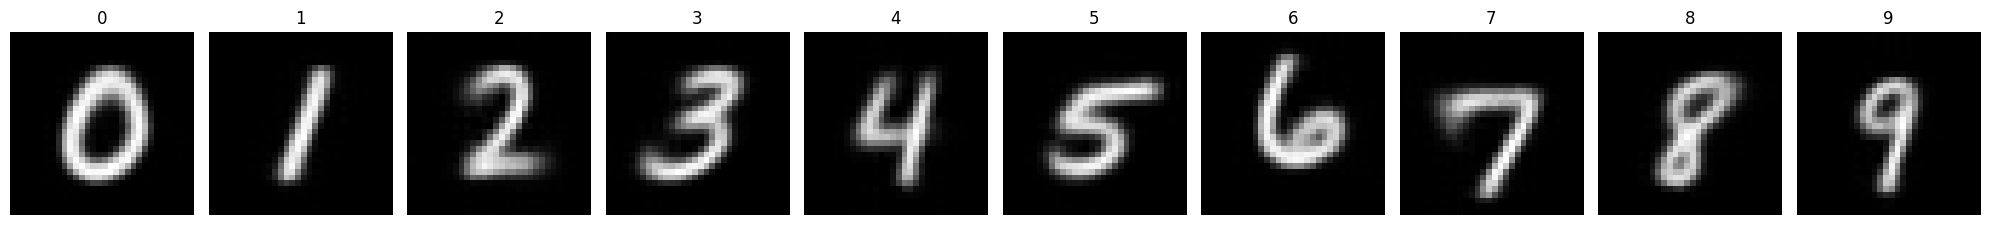

Epoch 28/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1280 - noise_loss: 0.0932 - kl_loss: 3.4739 - val_loss: 0.1253 - val_noise_loss: 0.0913 - val_image_loss: 0.0913 - val_kl_loss: 3.4036 - learning_rate: 8.1871e-04


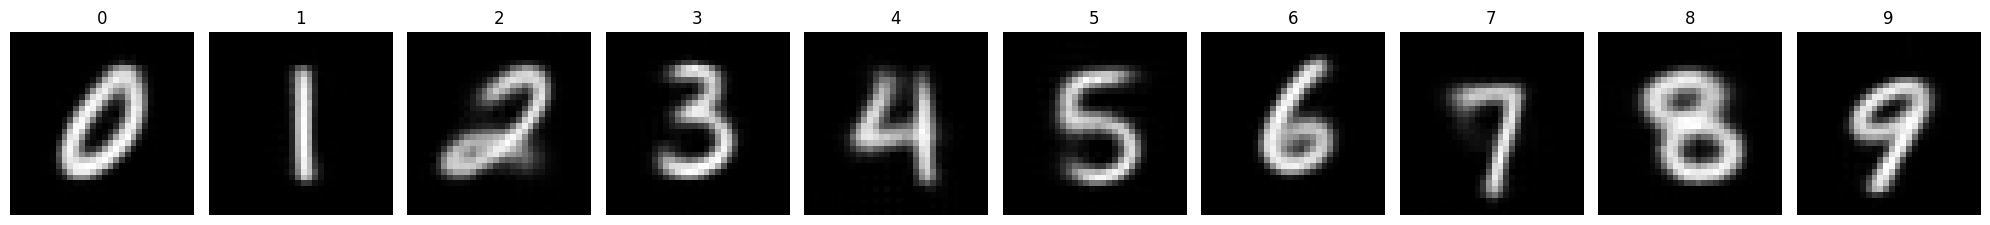

Epoch 29/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1279 - noise_loss: 0.0929 - kl_loss: 3.5004 - val_loss: 0.1249 - val_noise_loss: 0.0906 - val_image_loss: 0.0906 - val_kl_loss: 3.4256 - learning_rate: 8.0645e-04


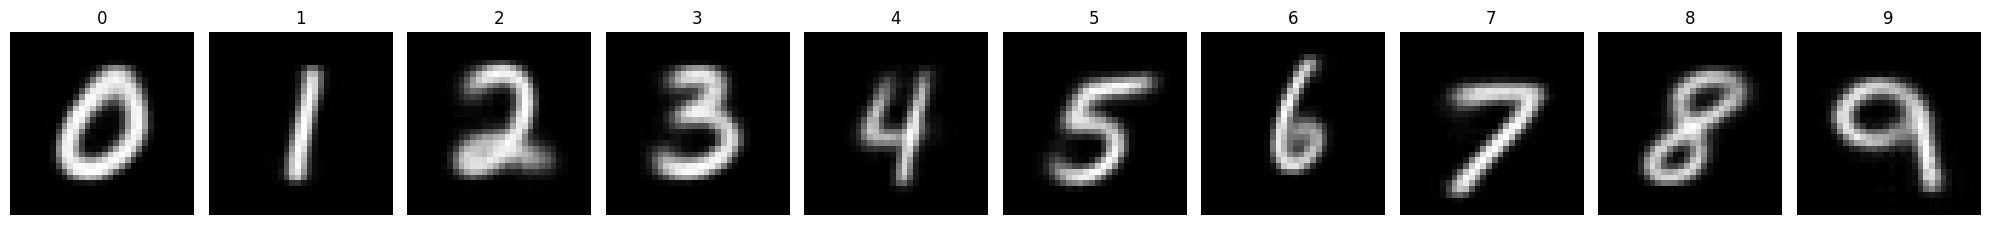

Epoch 30/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1279 - noise_loss: 0.0926 - kl_loss: 3.5268 - val_loss: 0.1248 - val_noise_loss: 0.0902 - val_image_loss: 0.0902 - val_kl_loss: 3.4539 - learning_rate: 7.9389e-04


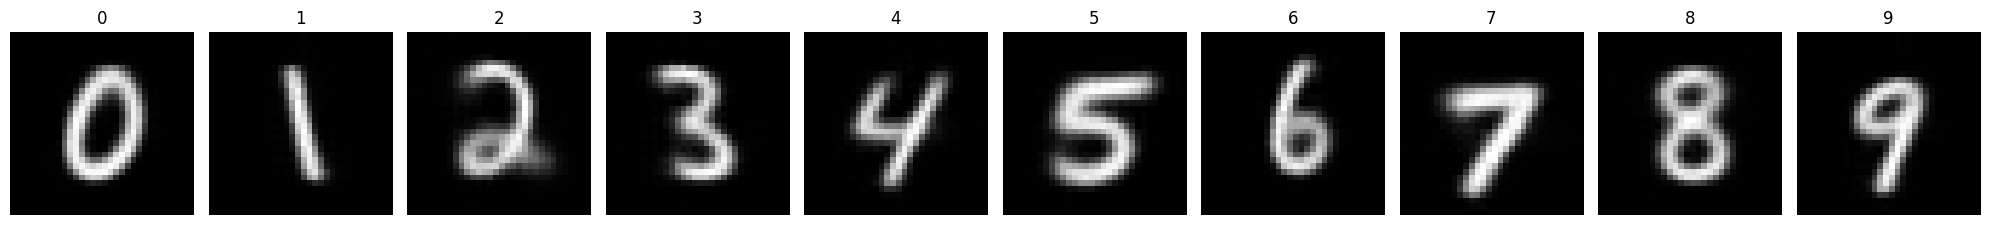

Epoch 31/100
468/468 [==============================] - 52s 112ms/step - loss: 0.1276 - noise_loss: 0.0923 - kl_loss: 3.5307 - val_loss: 0.1250 - val_noise_loss: 0.0903 - val_image_loss: 0.0903 - val_kl_loss: 3.4706 - learning_rate: 7.8104e-04


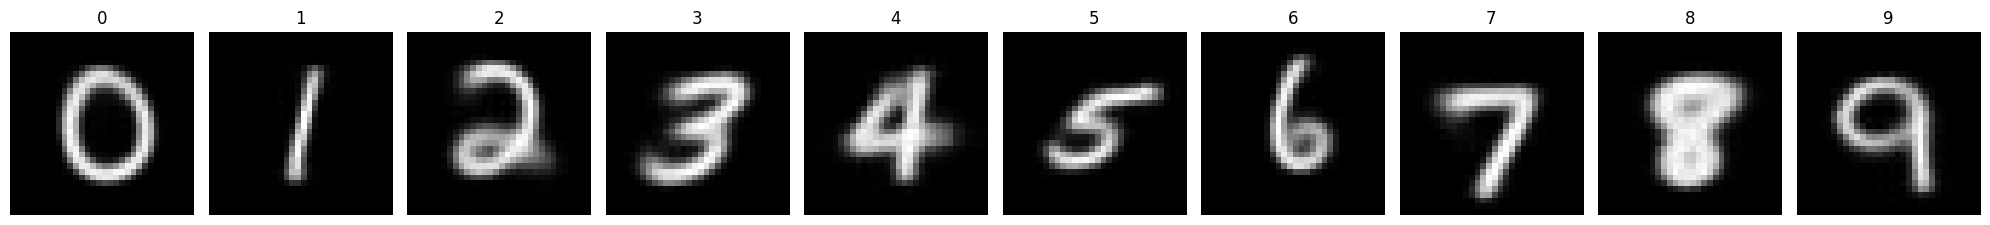

Epoch 32/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1275 - noise_loss: 0.0920 - kl_loss: 3.5511 - val_loss: 0.1251 - val_noise_loss: 0.0902 - val_image_loss: 0.0902 - val_kl_loss: 3.4890 - learning_rate: 7.6791e-04


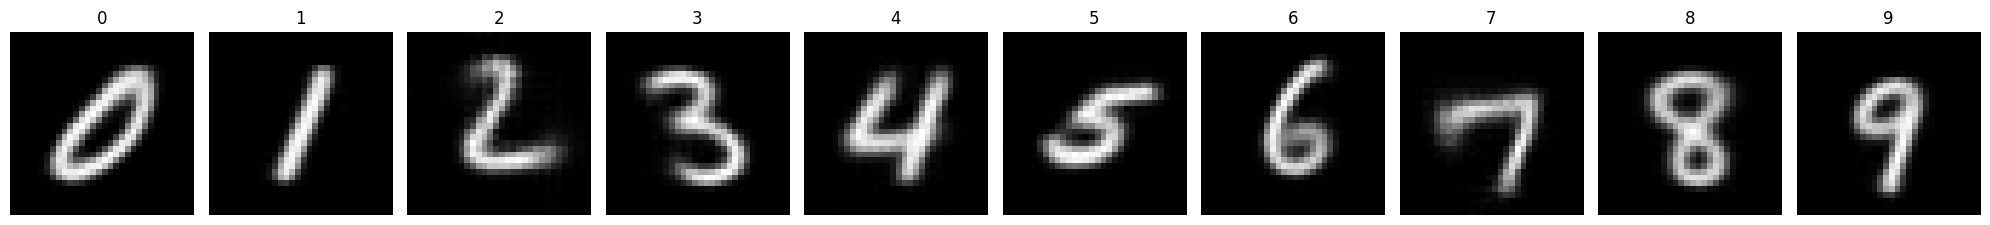

Epoch 33/100
468/468 [==============================] - 53s 112ms/step - loss: 0.1273 - noise_loss: 0.0919 - kl_loss: 3.5442 - val_loss: 0.1248 - val_noise_loss: 0.0898 - val_image_loss: 0.0898 - val_kl_loss: 3.4995 - learning_rate: 7.5452e-04


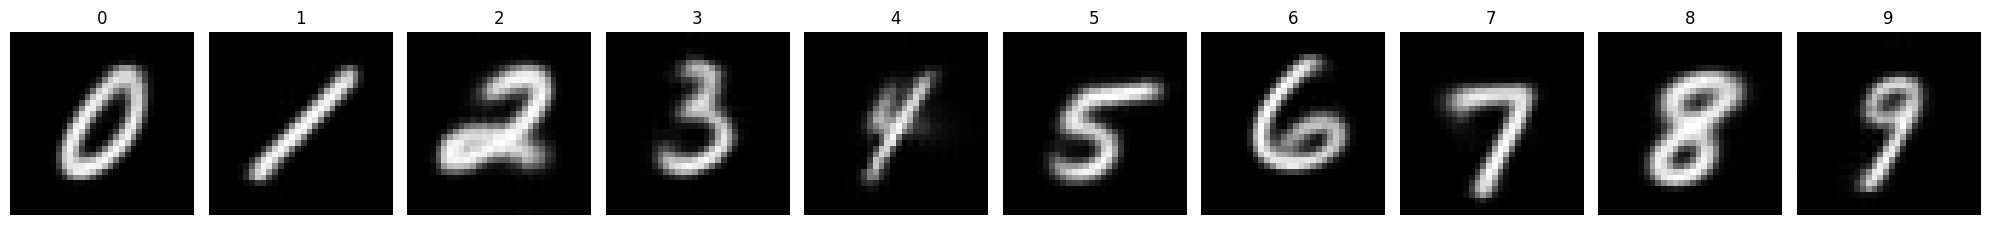

Epoch 34/100
468/468 [==============================] - 53s 113ms/step - loss: 0.1272 - noise_loss: 0.0915 - kl_loss: 3.5724 - val_loss: 0.1246 - val_noise_loss: 0.0894 - val_image_loss: 0.0894 - val_kl_loss: 3.5161 - learning_rate: 7.4088e-04


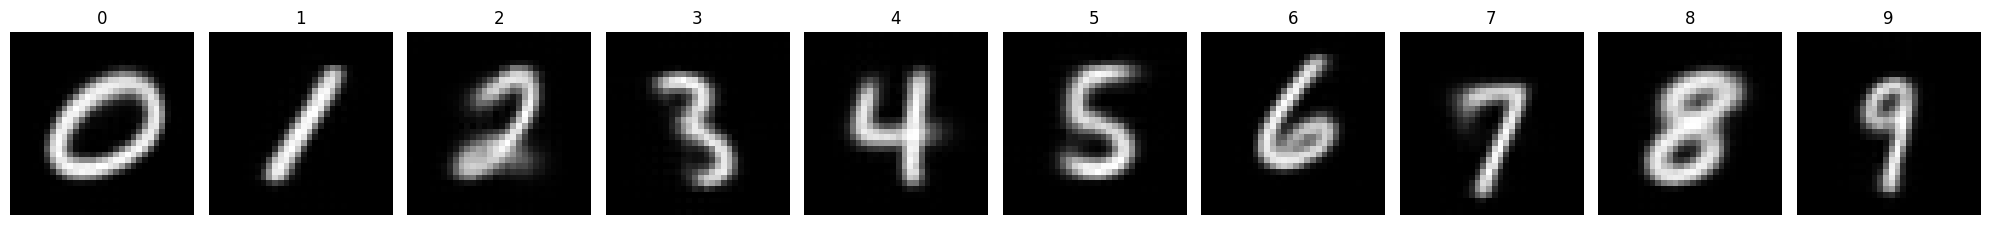

Epoch 35/100
468/468 [==============================] - 52s 111ms/step - loss: 0.1270 - noise_loss: 0.0913 - kl_loss: 3.5681 - val_loss: 0.1246 - val_noise_loss: 0.0893 - val_image_loss: 0.0893 - val_kl_loss: 3.5270 - learning_rate: 7.2700e-04


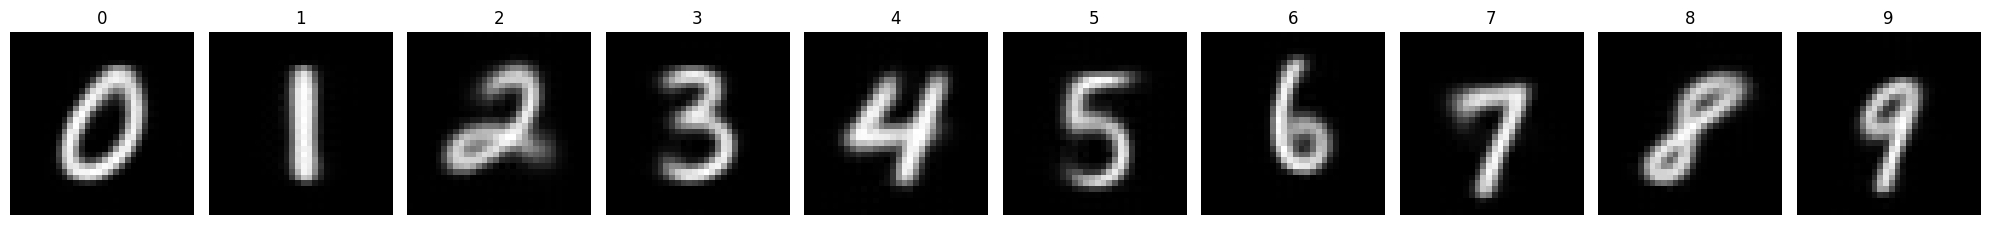

Epoch 36/100
468/468 [==============================] - 51s 109ms/step - loss: 0.1268 - noise_loss: 0.0909 - kl_loss: 3.5880 - val_loss: 0.1246 - val_noise_loss: 0.0892 - val_image_loss: 0.0892 - val_kl_loss: 3.5400 - learning_rate: 7.1289e-04


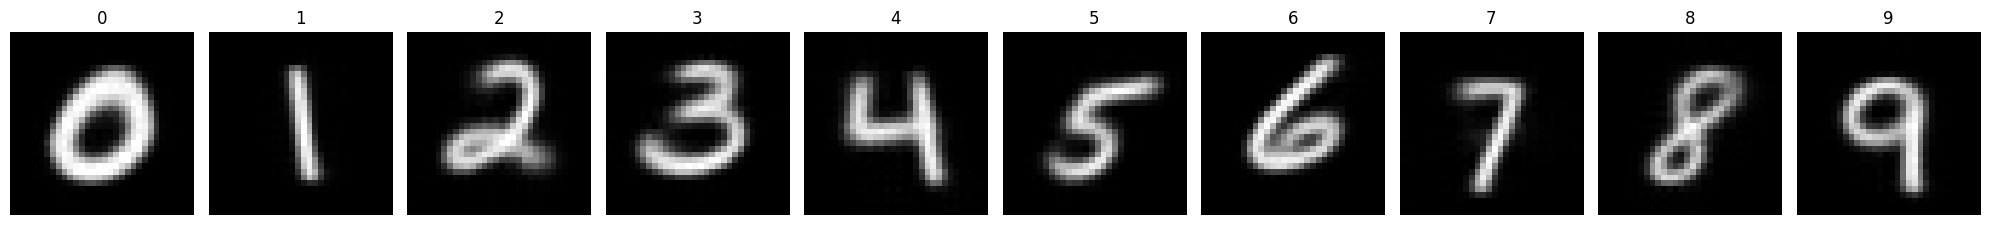

Epoch 37/100
468/468 [==============================] - 51s 109ms/step - loss: 0.1268 - noise_loss: 0.0907 - kl_loss: 3.6069 - val_loss: 0.1244 - val_noise_loss: 0.0889 - val_image_loss: 0.0889 - val_kl_loss: 3.5551 - learning_rate: 6.9857e-04


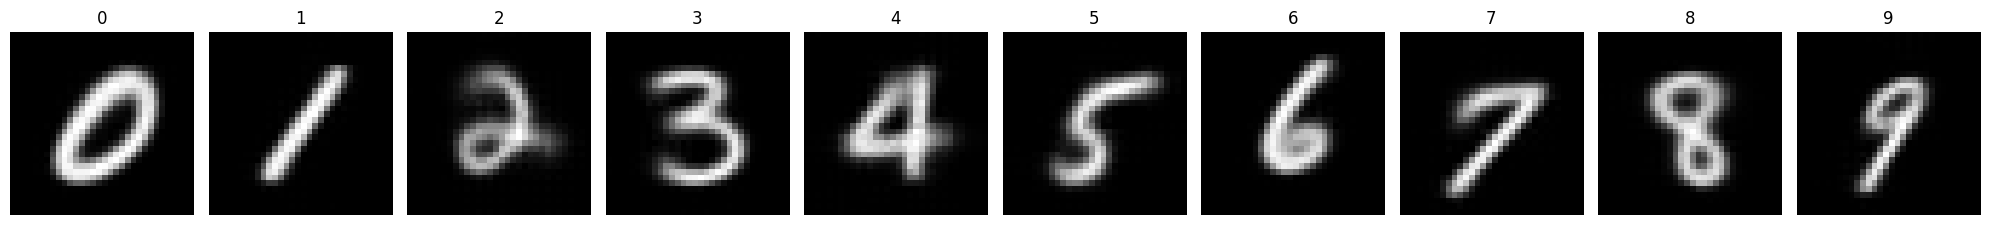

Epoch 38/100
468/468 [==============================] - 51s 110ms/step - loss: 0.1267 - noise_loss: 0.0906 - kl_loss: 3.6108 - val_loss: 0.1246 - val_noise_loss: 0.0890 - val_image_loss: 0.0890 - val_kl_loss: 3.5666 - learning_rate: 6.8406e-04


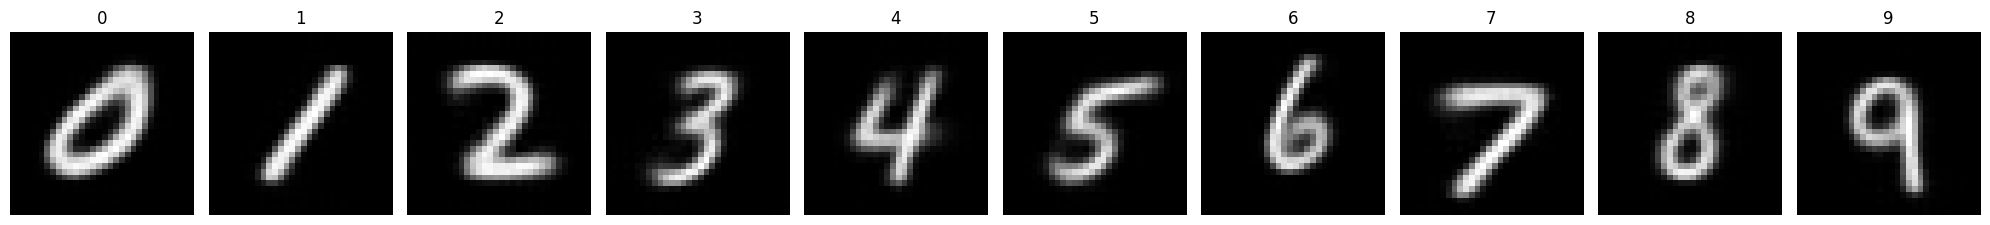

Epoch 39/100
468/468 [==============================] - 51s 110ms/step - loss: 0.1266 - noise_loss: 0.0903 - kl_loss: 3.6318 - val_loss: 0.1239 - val_noise_loss: 0.0881 - val_image_loss: 0.0881 - val_kl_loss: 3.5822 - learning_rate: 6.6937e-04


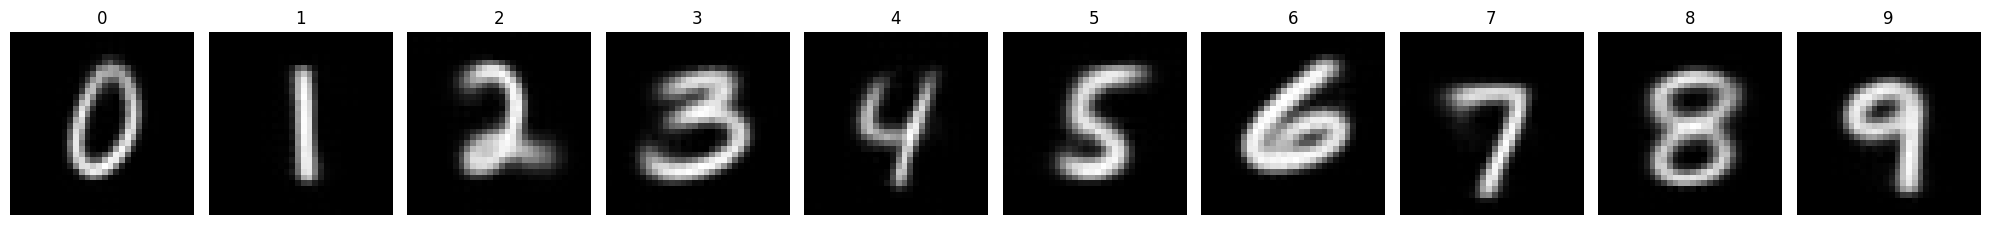

Epoch 40/100
468/468 [==============================] - 51s 110ms/step - loss: 0.1264 - noise_loss: 0.0901 - kl_loss: 3.6350 - val_loss: 0.1243 - val_noise_loss: 0.0883 - val_image_loss: 0.0883 - val_kl_loss: 3.5936 - learning_rate: 6.5451e-04


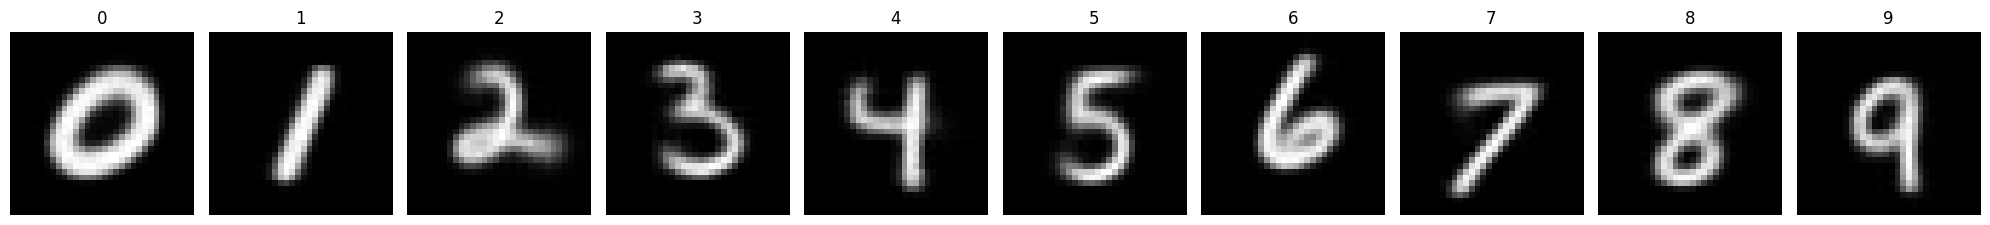

Epoch 41/100
468/468 [==============================] - 51s 110ms/step - loss: 0.1263 - noise_loss: 0.0898 - kl_loss: 3.6485 - val_loss: 0.1241 - val_noise_loss: 0.0880 - val_image_loss: 0.0880 - val_kl_loss: 3.6066 - learning_rate: 6.3950e-04


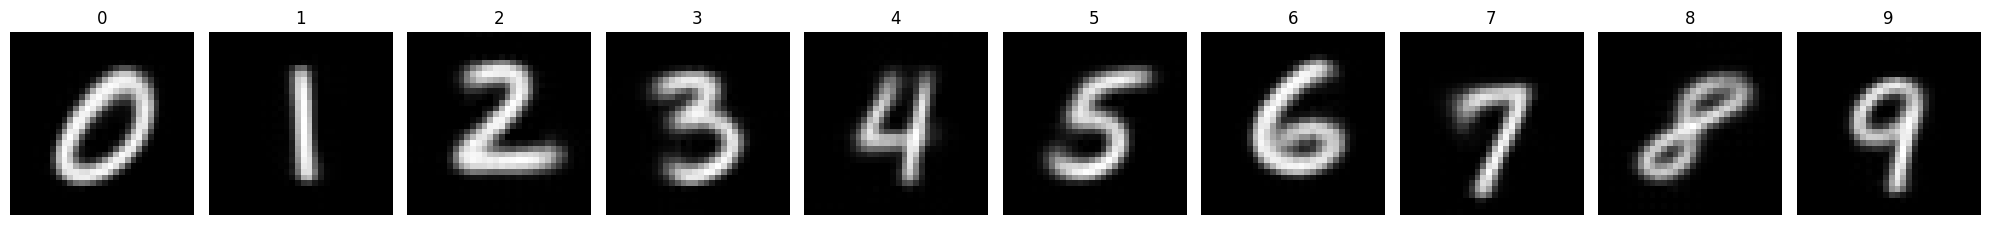

Epoch 42/100
468/468 [==============================] - 51s 109ms/step - loss: 0.1262 - noise_loss: 0.0896 - kl_loss: 3.6594 - val_loss: 0.1239 - val_noise_loss: 0.0877 - val_image_loss: 0.0877 - val_kl_loss: 3.6184 - learning_rate: 6.2435e-04


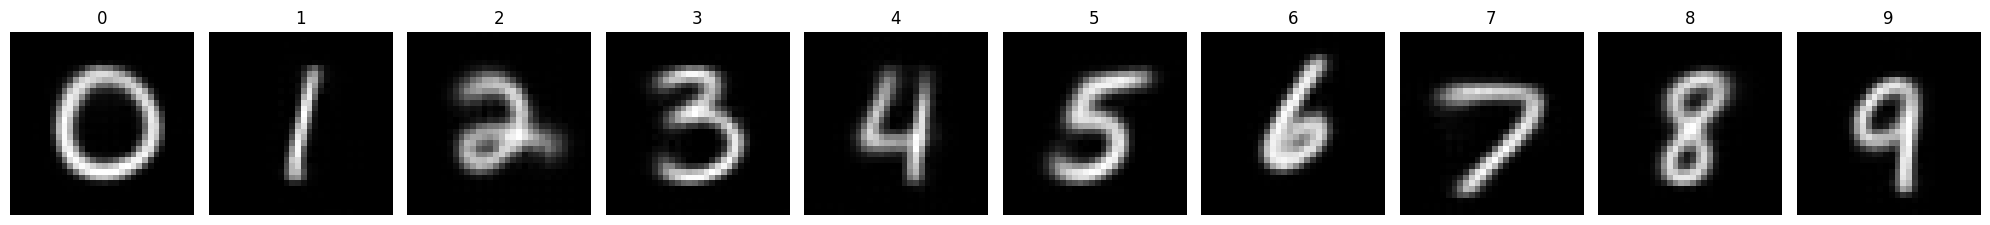

Epoch 43/100
468/468 [==============================] - 51s 109ms/step - loss: 0.1261 - noise_loss: 0.0894 - kl_loss: 3.6732 - val_loss: 0.1242 - val_noise_loss: 0.0879 - val_image_loss: 0.0879 - val_kl_loss: 3.6298 - learning_rate: 6.0907e-04


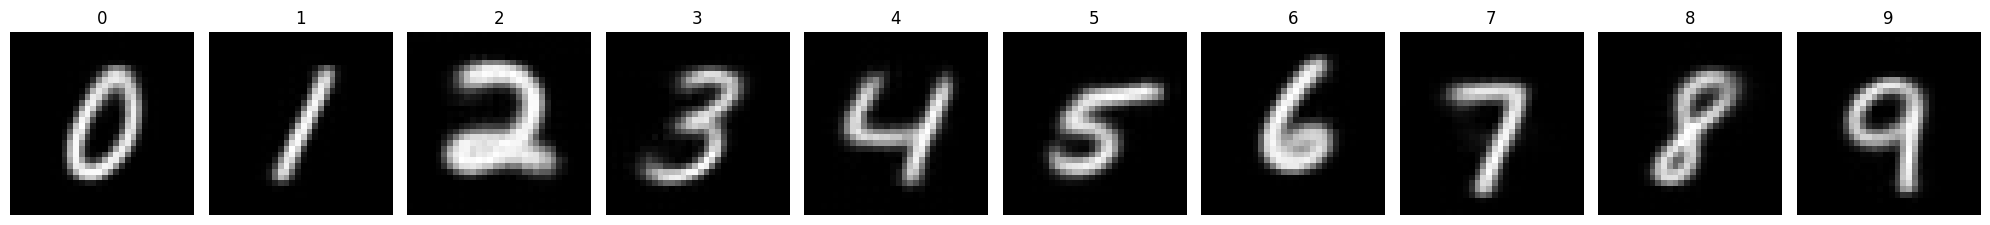

Epoch 44/100
468/468 [==============================] - 51s 110ms/step - loss: 0.1259 - noise_loss: 0.0891 - kl_loss: 3.6804 - val_loss: 0.1241 - val_noise_loss: 0.0877 - val_image_loss: 0.0877 - val_kl_loss: 3.6417 - learning_rate: 5.9369e-04


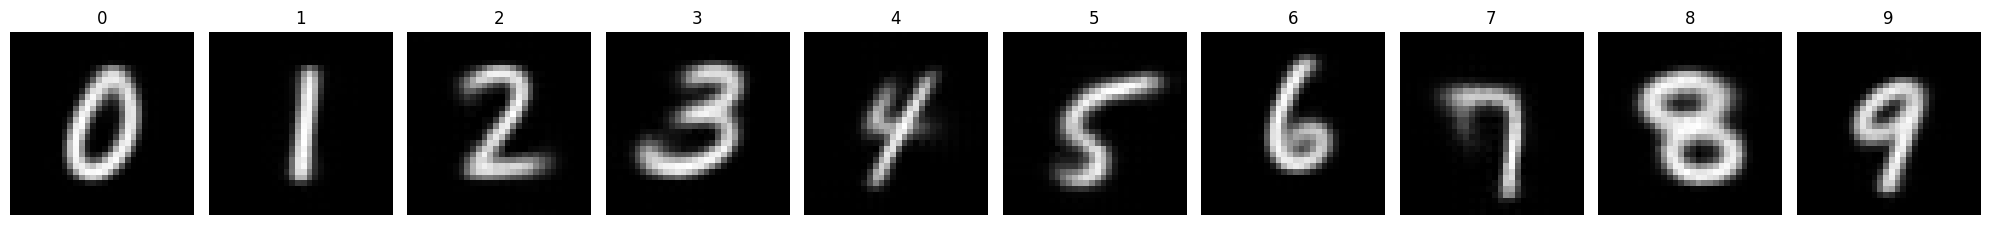

Epoch 45/100
468/468 [==============================] - 52s 110ms/step - loss: 0.1258 - noise_loss: 0.0889 - kl_loss: 3.6907 - val_loss: 0.1241 - val_noise_loss: 0.0875 - val_image_loss: 0.0875 - val_kl_loss: 3.6525 - learning_rate: 5.7822e-04


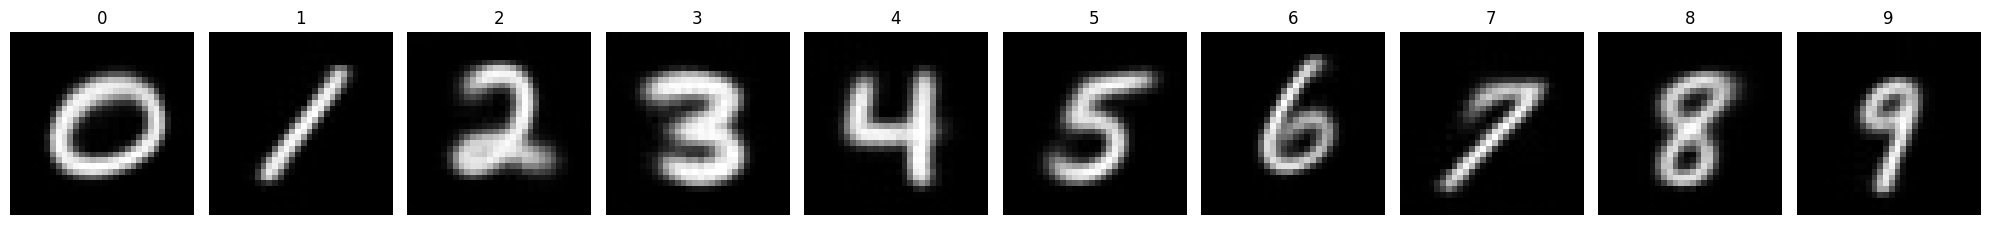

Epoch 46/100
468/468 [==============================] - 51s 110ms/step - loss: 0.1258 - noise_loss: 0.0889 - kl_loss: 3.6966 - val_loss: 0.1243 - val_noise_loss: 0.0876 - val_image_loss: 0.0876 - val_kl_loss: 3.6627 - learning_rate: 5.6267e-04


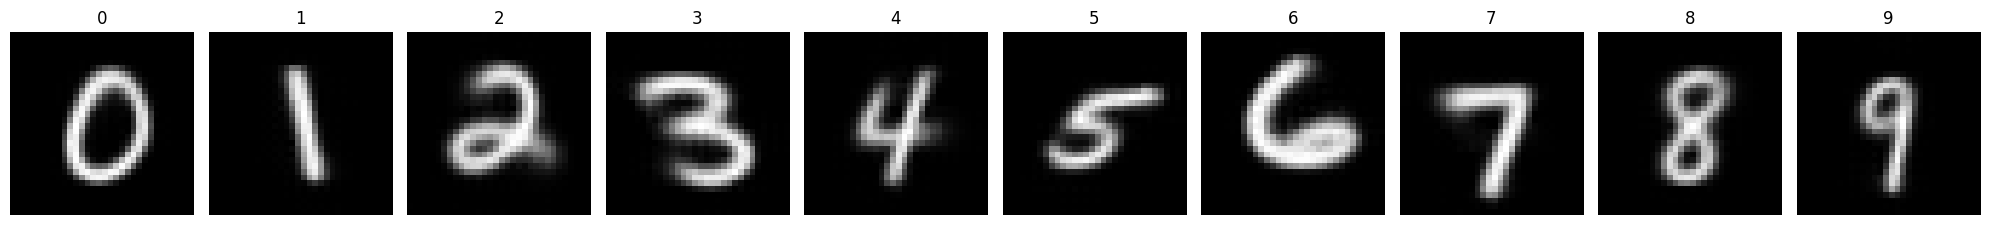

Epoch 47/100
468/468 [==============================] - 51s 110ms/step - loss: 0.1258 - noise_loss: 0.0887 - kl_loss: 3.7039 - val_loss: 0.1236 - val_noise_loss: 0.0869 - val_image_loss: 0.0869 - val_kl_loss: 3.6733 - learning_rate: 5.4705e-04


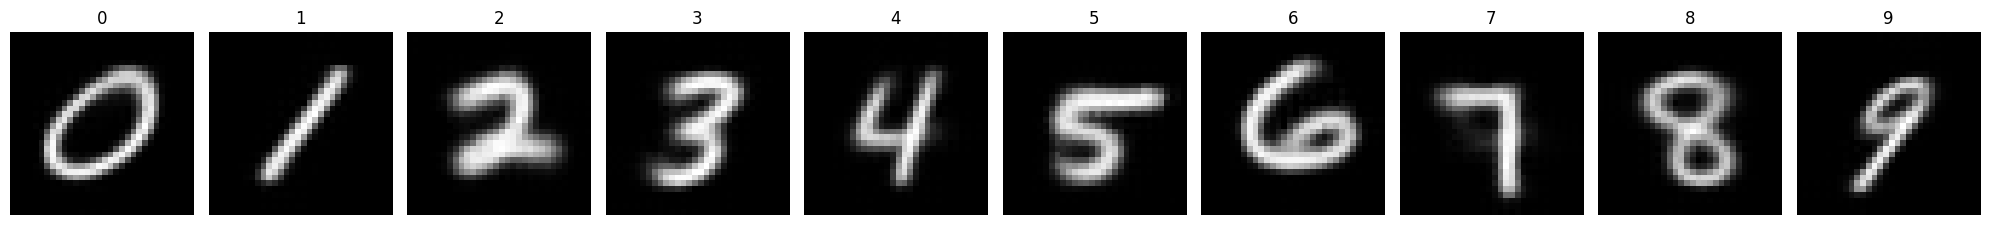

Epoch 48/100
468/468 [==============================] - 58s 124ms/step - loss: 0.1257 - noise_loss: 0.0886 - kl_loss: 3.7071 - val_loss: 0.1240 - val_noise_loss: 0.0872 - val_image_loss: 0.0872 - val_kl_loss: 3.6792 - learning_rate: 5.3140e-04


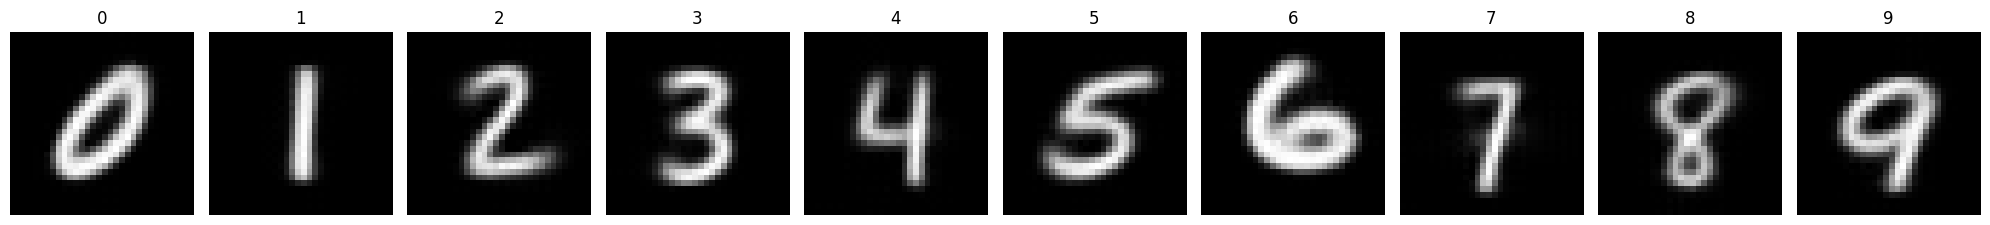

Epoch 49/100
468/468 [==============================] - 92s 198ms/step - loss: 0.1257 - noise_loss: 0.0885 - kl_loss: 3.7269 - val_loss: 0.1235 - val_noise_loss: 0.0866 - val_image_loss: 0.0866 - val_kl_loss: 3.6899 - learning_rate: 5.1571e-04


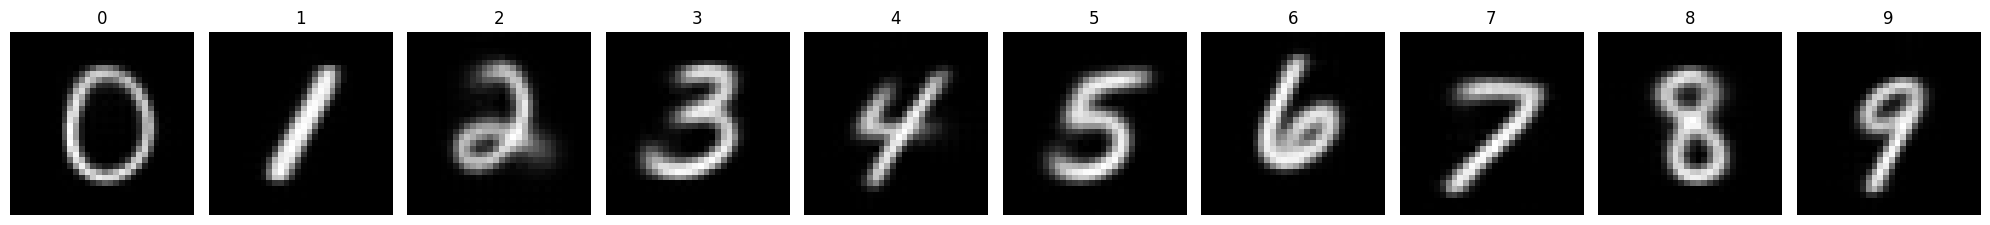

Epoch 50/100
468/468 [==============================] - 93s 199ms/step - loss: 0.1254 - noise_loss: 0.0881 - kl_loss: 3.7372 - val_loss: 0.1238 - val_noise_loss: 0.0868 - val_image_loss: 0.0868 - val_kl_loss: 3.6999 - learning_rate: 5.0000e-04


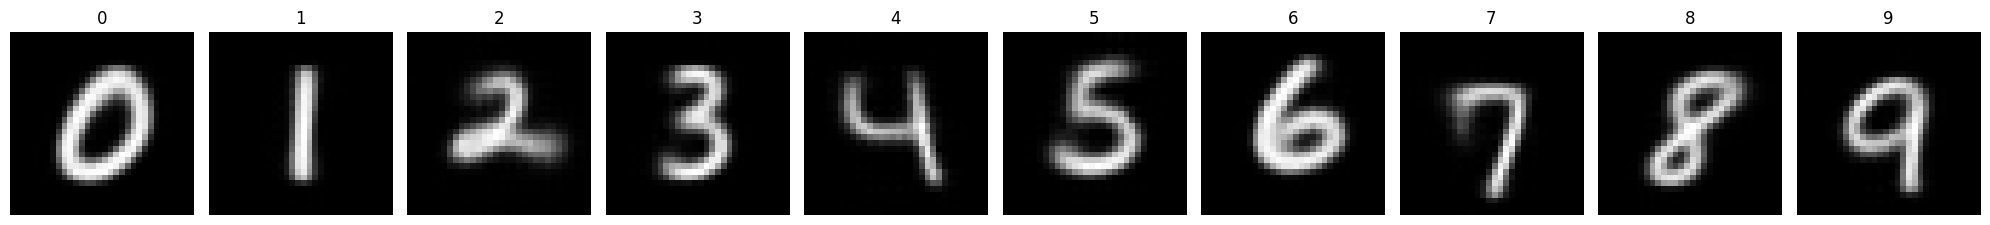

Epoch 51/100
468/468 [==============================] - 93s 199ms/step - loss: 0.1252 - noise_loss: 0.0880 - kl_loss: 3.7250 - val_loss: 0.1234 - val_noise_loss: 0.0864 - val_image_loss: 0.0864 - val_kl_loss: 3.7011 - learning_rate: 4.8429e-04


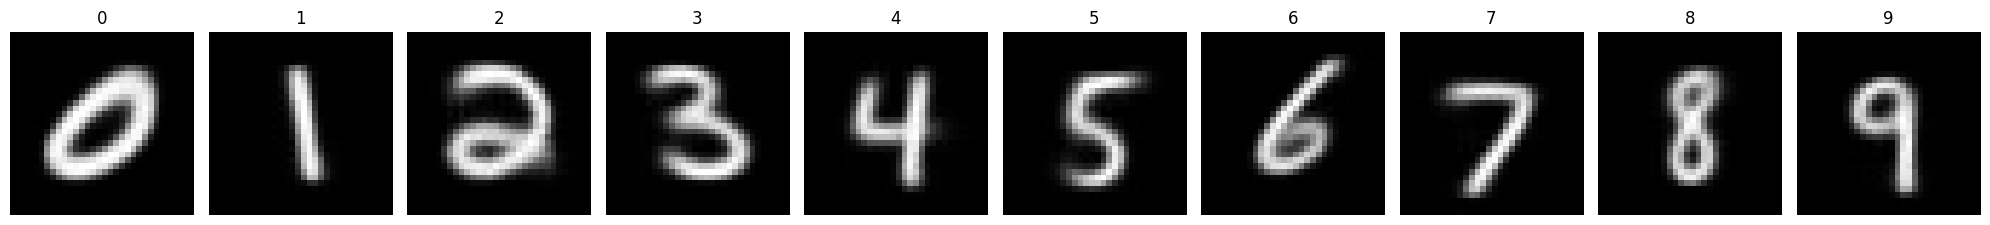

Epoch 52/100
468/468 [==============================] - 100s 214ms/step - loss: 0.1252 - noise_loss: 0.0878 - kl_loss: 3.7434 - val_loss: 0.1235 - val_noise_loss: 0.0864 - val_image_loss: 0.0864 - val_kl_loss: 3.7110 - learning_rate: 4.6860e-04


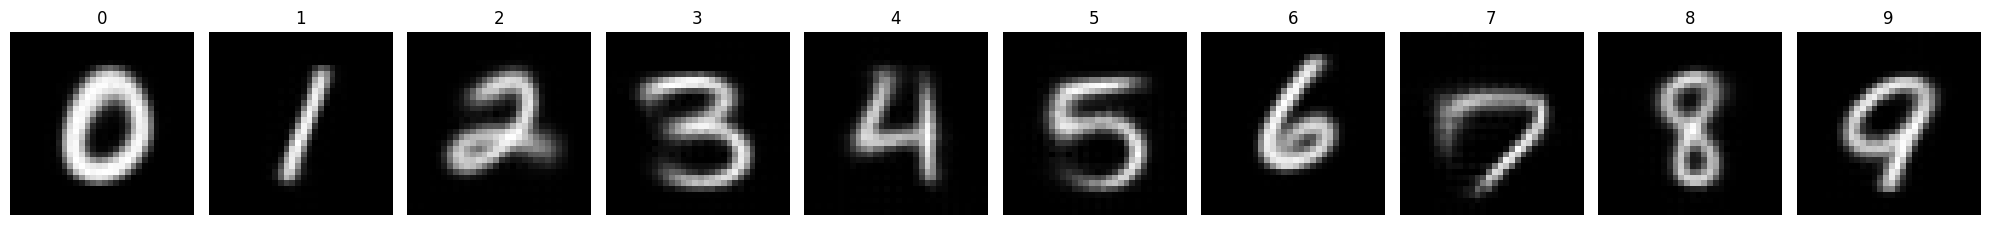

Epoch 53/100
468/468 [==============================] - 95s 202ms/step - loss: 0.1252 - noise_loss: 0.0877 - kl_loss: 3.7545 - val_loss: 0.1236 - val_noise_loss: 0.0864 - val_image_loss: 0.0864 - val_kl_loss: 3.7204 - learning_rate: 4.5295e-04


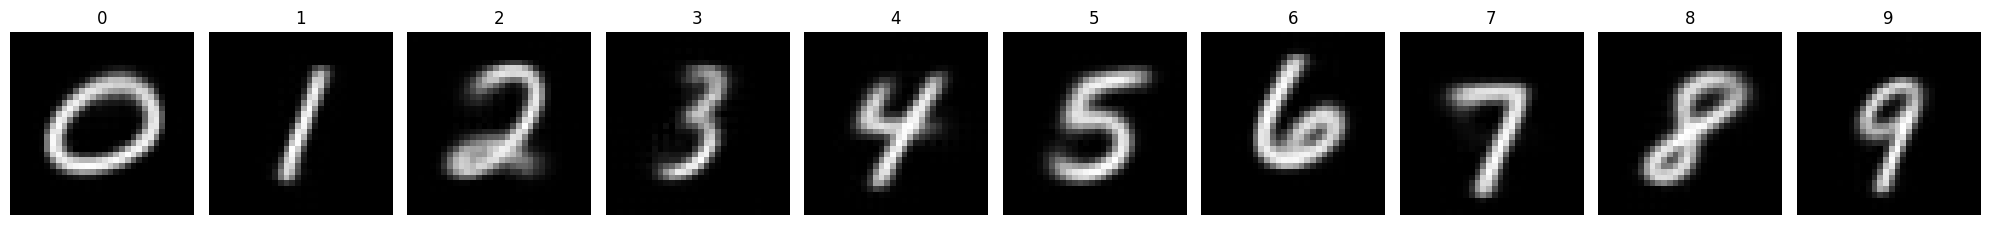

Epoch 54/100
468/468 [==============================] - 103s 220ms/step - loss: 0.1250 - noise_loss: 0.0875 - kl_loss: 3.7520 - val_loss: 0.1239 - val_noise_loss: 0.0866 - val_image_loss: 0.0866 - val_kl_loss: 3.7263 - learning_rate: 4.3733e-04


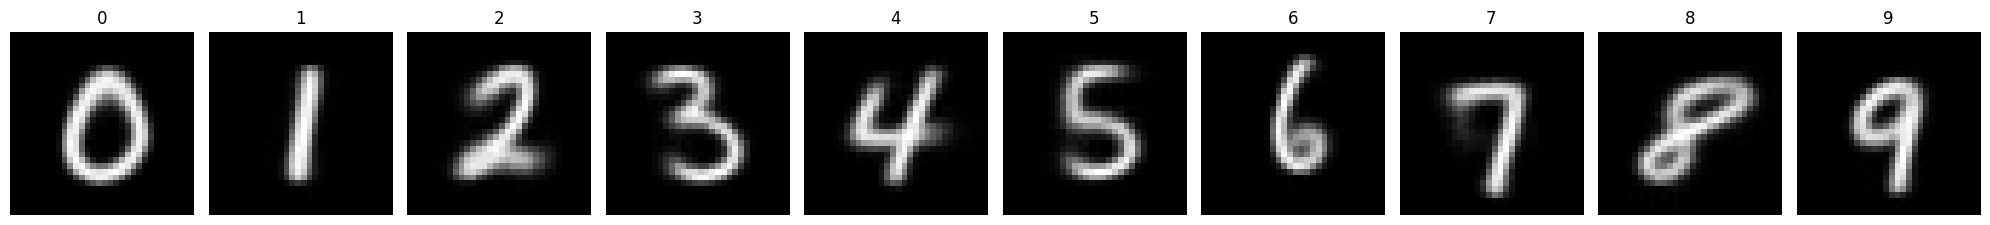

Epoch 55/100
468/468 [==============================] - 112s 238ms/step - loss: 0.1249 - noise_loss: 0.0873 - kl_loss: 3.7618 - val_loss: 0.1236 - val_noise_loss: 0.0863 - val_image_loss: 0.0863 - val_kl_loss: 3.7323 - learning_rate: 4.2178e-04


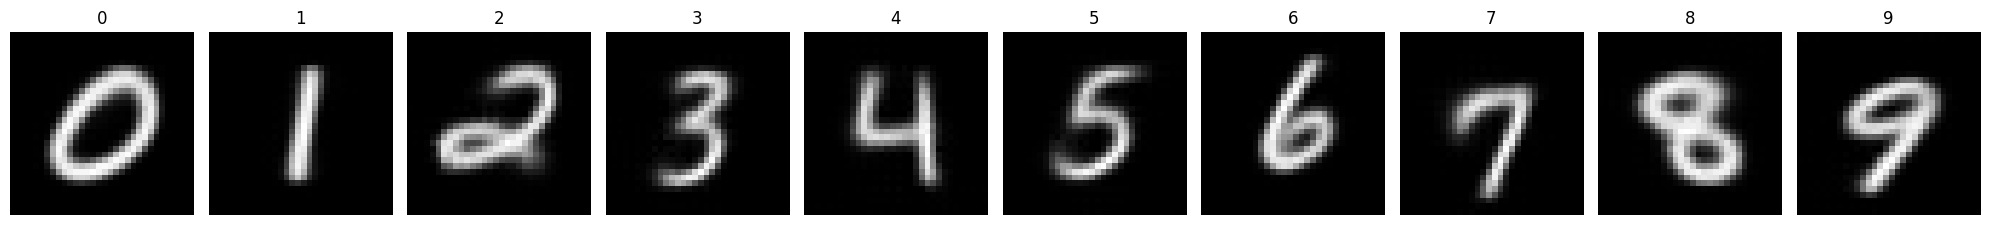

Epoch 56/100
468/468 [==============================] - 92s 196ms/step - loss: 0.1249 - noise_loss: 0.0872 - kl_loss: 3.7720 - val_loss: 0.1237 - val_noise_loss: 0.0863 - val_image_loss: 0.0863 - val_kl_loss: 3.7419 - learning_rate: 4.0631e-04


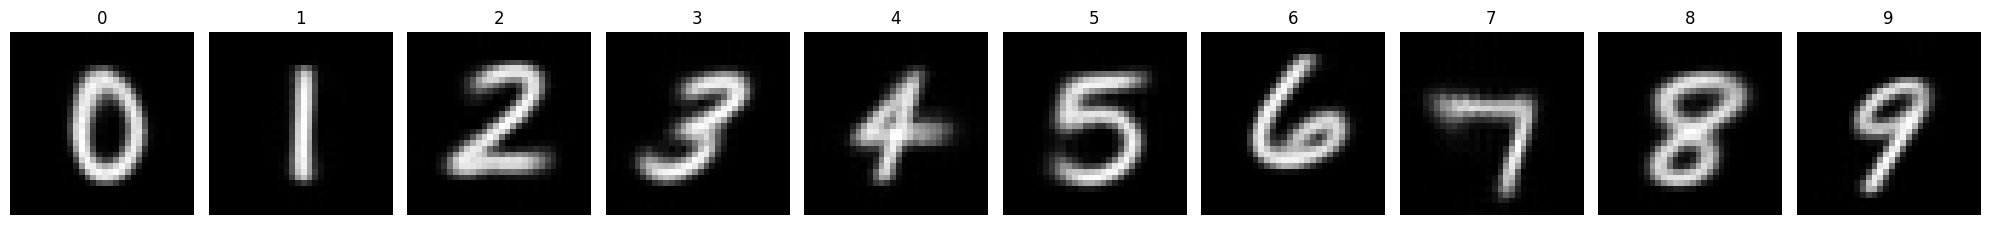

Epoch 57/100
468/468 [==============================] - 96s 205ms/step - loss: 0.1247 - noise_loss: 0.0870 - kl_loss: 3.7728 - val_loss: 0.1236 - val_noise_loss: 0.0861 - val_image_loss: 0.0861 - val_kl_loss: 3.7479 - learning_rate: 3.9093e-04


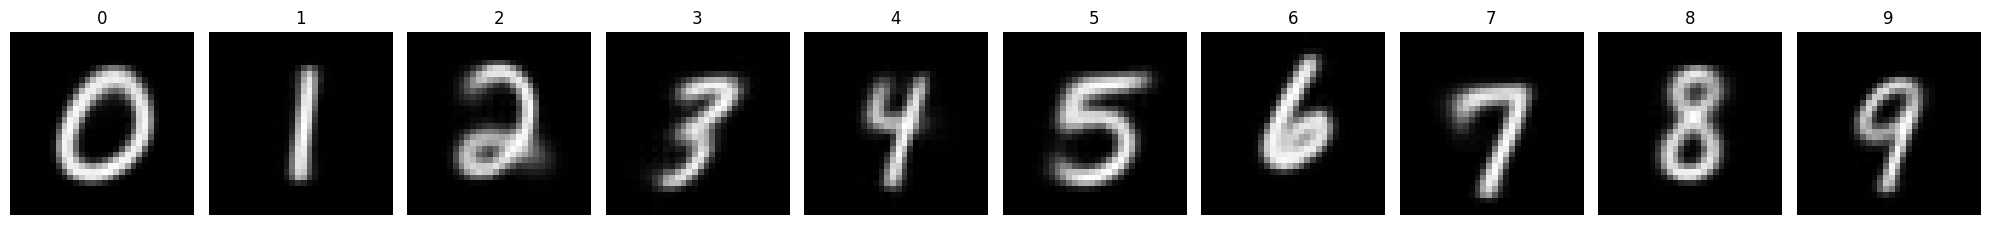

Epoch 58/100
468/468 [==============================] - 87s 186ms/step - loss: 0.1247 - noise_loss: 0.0869 - kl_loss: 3.7817 - val_loss: 0.1235 - val_noise_loss: 0.0860 - val_image_loss: 0.0860 - val_kl_loss: 3.7547 - learning_rate: 3.7566e-04


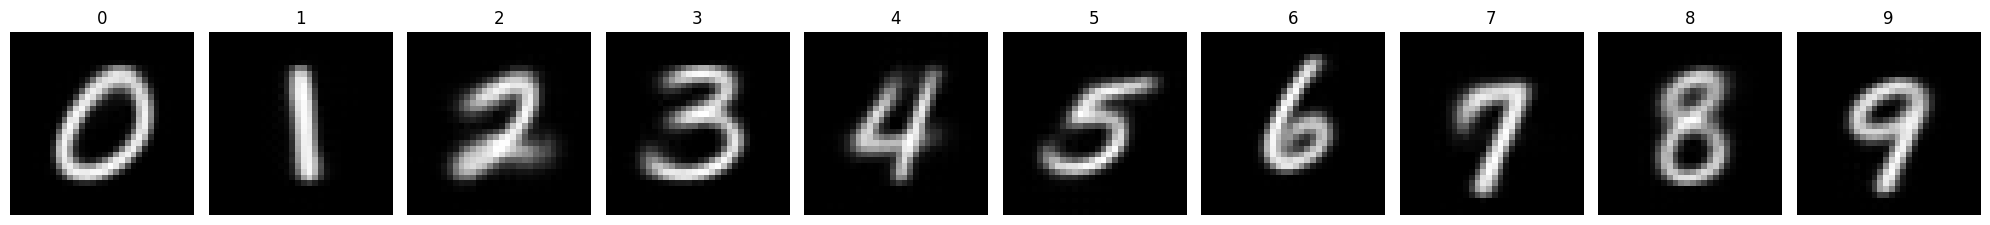

Epoch 59/100
468/468 [==============================] - 96s 205ms/step - loss: 0.1245 - noise_loss: 0.0868 - kl_loss: 3.7766 - val_loss: 0.1234 - val_noise_loss: 0.0858 - val_image_loss: 0.0858 - val_kl_loss: 3.7584 - learning_rate: 3.6050e-04


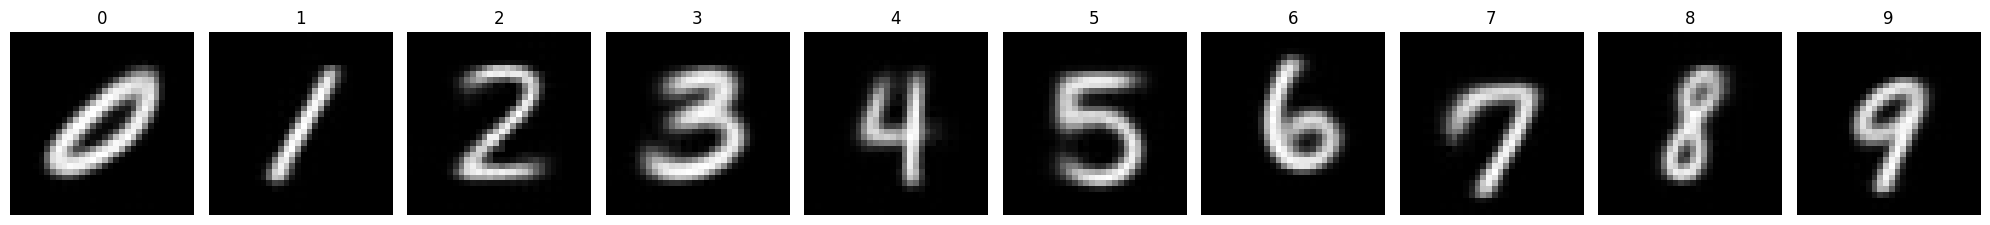

Epoch 60/100
468/468 [==============================] - 99s 212ms/step - loss: 0.1246 - noise_loss: 0.0866 - kl_loss: 3.8021 - val_loss: 0.1234 - val_noise_loss: 0.0857 - val_image_loss: 0.0857 - val_kl_loss: 3.7690 - learning_rate: 3.4549e-04


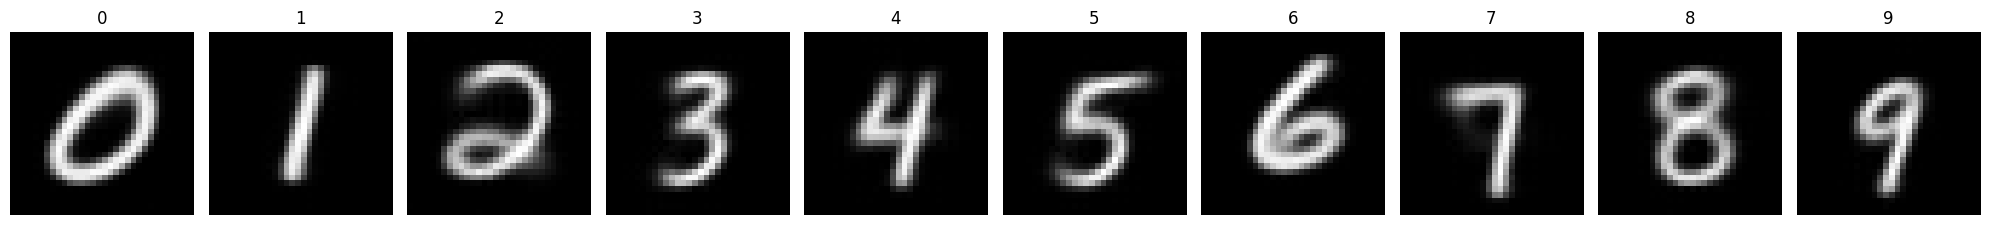

Epoch 61/100
468/468 [==============================] - 100s 213ms/step - loss: 0.1245 - noise_loss: 0.0865 - kl_loss: 3.8007 - val_loss: 0.1234 - val_noise_loss: 0.0856 - val_image_loss: 0.0856 - val_kl_loss: 3.7765 - learning_rate: 3.3063e-04


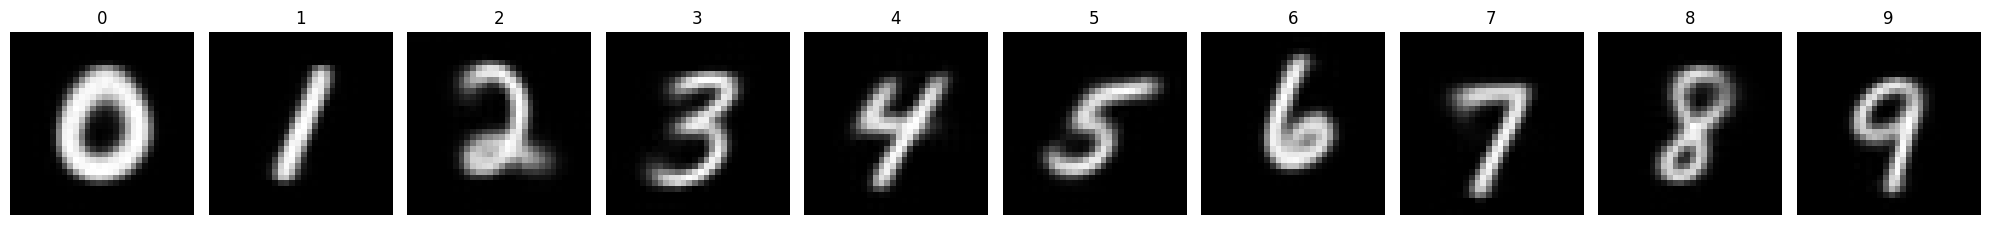

Epoch 62/100
468/468 [==============================] - 99s 211ms/step - loss: 0.1244 - noise_loss: 0.0863 - kl_loss: 3.8109 - val_loss: 0.1233 - val_noise_loss: 0.0854 - val_image_loss: 0.0854 - val_kl_loss: 3.7857 - learning_rate: 3.1594e-04


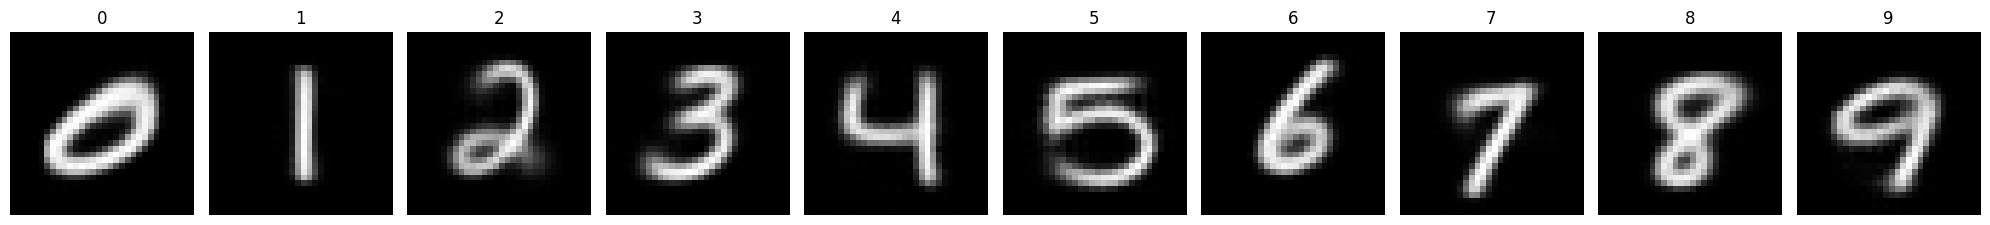

Epoch 63/100
468/468 [==============================] - 129s 253ms/step - loss: 0.1244 - noise_loss: 0.0862 - kl_loss: 3.8210 - val_loss: 0.1232 - val_noise_loss: 0.0852 - val_image_loss: 0.0852 - val_kl_loss: 3.7946 - learning_rate: 3.0143e-04


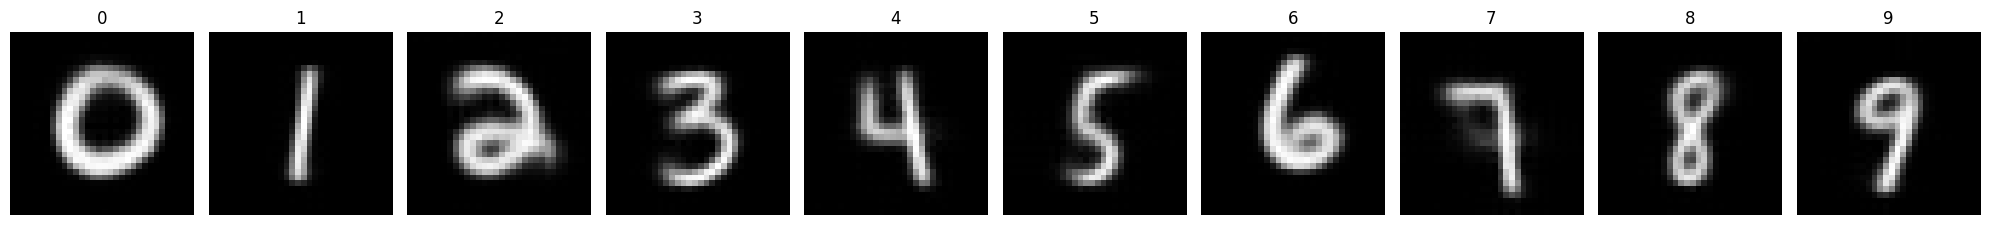

Epoch 64/100
468/468 [==============================] - 100s 214ms/step - loss: 0.1243 - noise_loss: 0.0860 - kl_loss: 3.8283 - val_loss: 0.1236 - val_noise_loss: 0.0855 - val_image_loss: 0.0855 - val_kl_loss: 3.8026 - learning_rate: 2.8711e-04


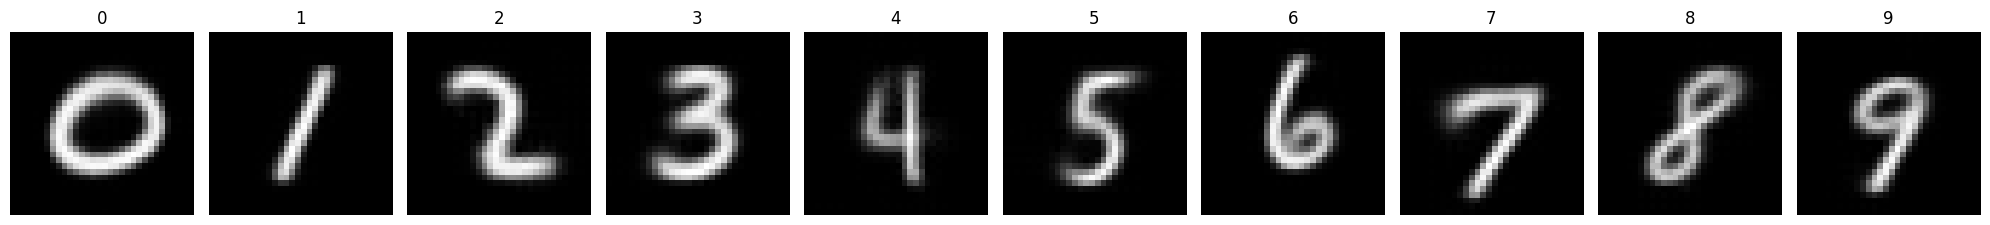

Epoch 65/100
468/468 [==============================] - 69s 146ms/step - loss: 0.1242 - noise_loss: 0.0859 - kl_loss: 3.8318 - val_loss: 0.1232 - val_noise_loss: 0.0851 - val_image_loss: 0.0851 - val_kl_loss: 3.8089 - learning_rate: 2.7300e-04


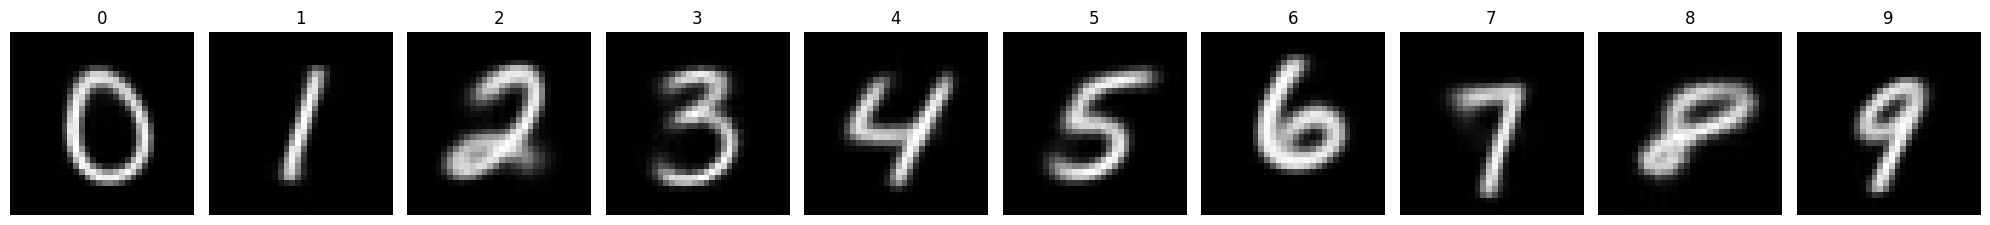

Epoch 66/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1242 - noise_loss: 0.0859 - kl_loss: 3.8342 - val_loss: 0.1232 - val_noise_loss: 0.0851 - val_image_loss: 0.0851 - val_kl_loss: 3.8123 - learning_rate: 2.5912e-04


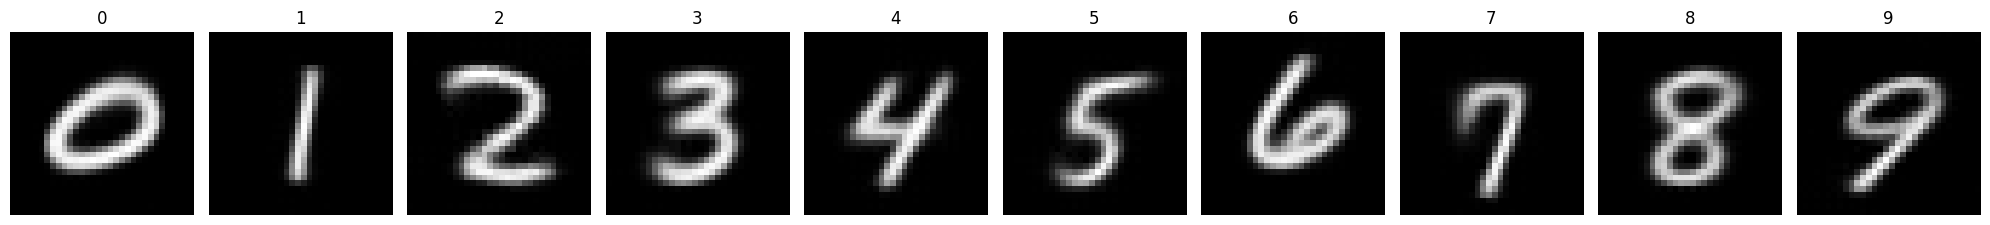

Epoch 67/100
468/468 [==============================] - 65s 140ms/step - loss: 0.1240 - noise_loss: 0.0857 - kl_loss: 3.8359 - val_loss: 0.1234 - val_noise_loss: 0.0853 - val_image_loss: 0.0853 - val_kl_loss: 3.8172 - learning_rate: 2.4548e-04


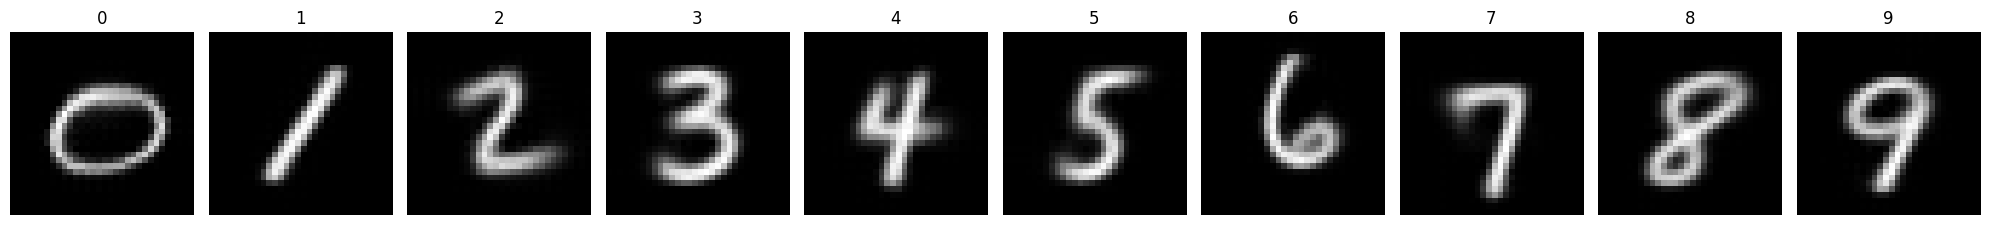

Epoch 68/100
468/468 [==============================] - 66s 142ms/step - loss: 0.1241 - noise_loss: 0.0857 - kl_loss: 3.8377 - val_loss: 0.1233 - val_noise_loss: 0.0850 - val_image_loss: 0.0850 - val_kl_loss: 3.8206 - learning_rate: 2.3209e-04


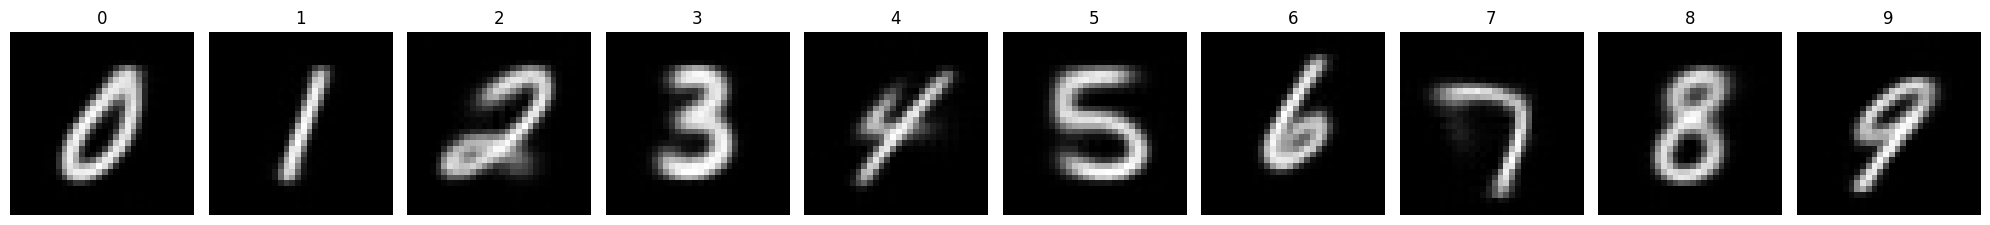

Epoch 69/100
468/468 [==============================] - 65s 139ms/step - loss: 0.1240 - noise_loss: 0.0855 - kl_loss: 3.8453 - val_loss: 0.1230 - val_noise_loss: 0.0847 - val_image_loss: 0.0847 - val_kl_loss: 3.8241 - learning_rate: 2.1896e-04


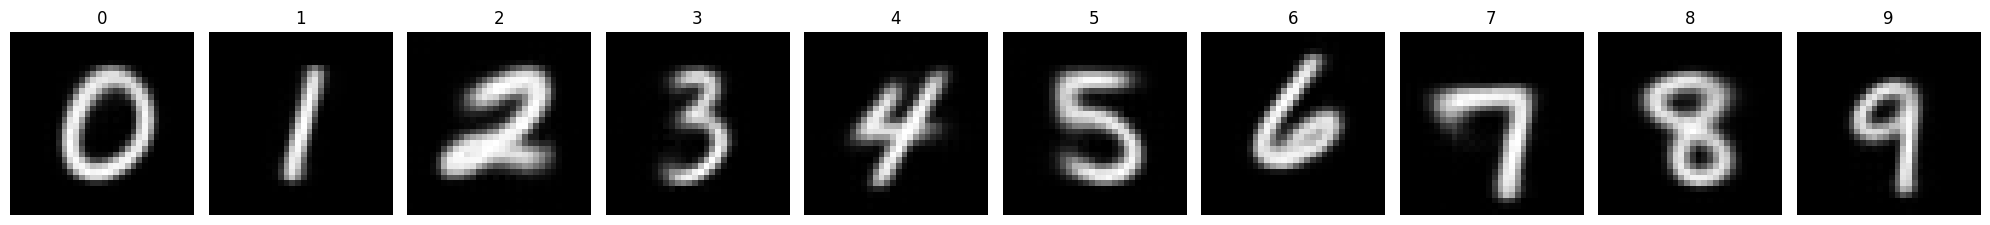

Epoch 70/100
468/468 [==============================] - 68s 144ms/step - loss: 0.1241 - noise_loss: 0.0855 - kl_loss: 3.8622 - val_loss: 0.1232 - val_noise_loss: 0.0849 - val_image_loss: 0.0849 - val_kl_loss: 3.8328 - learning_rate: 2.0611e-04


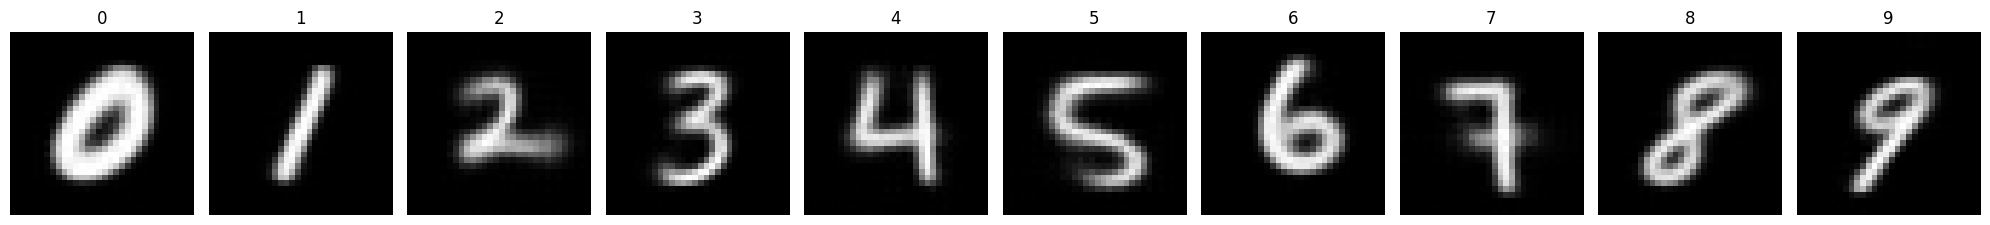

Epoch 71/100
468/468 [==============================] - 66s 142ms/step - loss: 0.1240 - noise_loss: 0.0853 - kl_loss: 3.8680 - val_loss: 0.1233 - val_noise_loss: 0.0849 - val_image_loss: 0.0849 - val_kl_loss: 3.8414 - learning_rate: 1.9355e-04


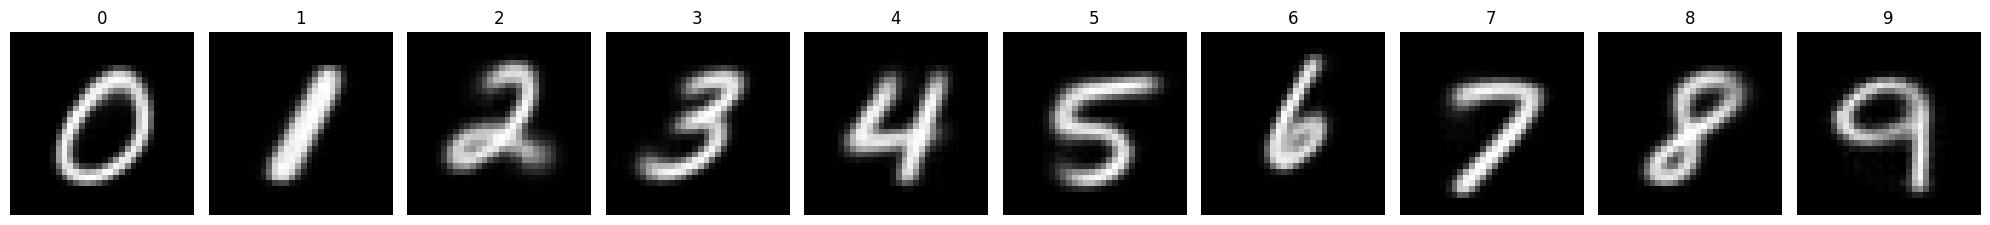

Epoch 72/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1239 - noise_loss: 0.0852 - kl_loss: 3.8701 - val_loss: 0.1231 - val_noise_loss: 0.0846 - val_image_loss: 0.0846 - val_kl_loss: 3.8470 - learning_rate: 1.8129e-04


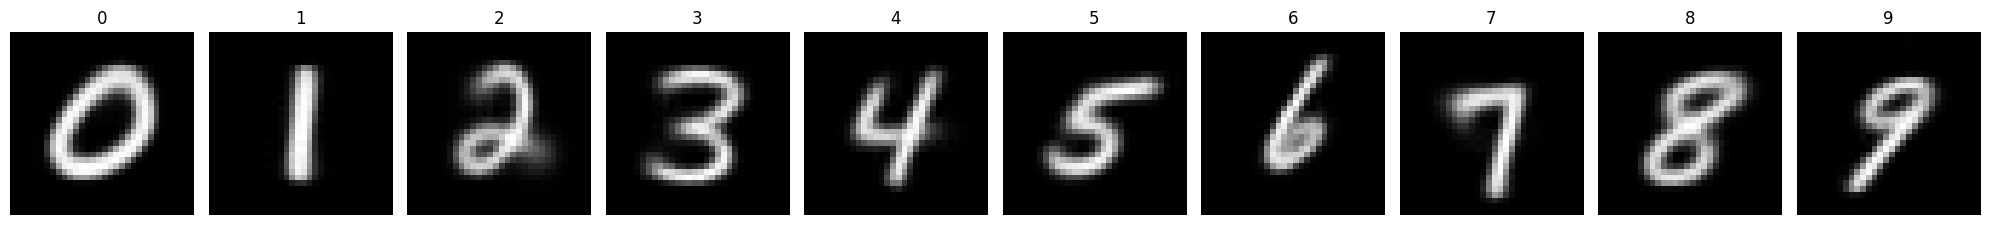

Epoch 73/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1237 - noise_loss: 0.0851 - kl_loss: 3.8615 - val_loss: 0.1234 - val_noise_loss: 0.0849 - val_image_loss: 0.0849 - val_kl_loss: 3.8466 - learning_rate: 1.6934e-04


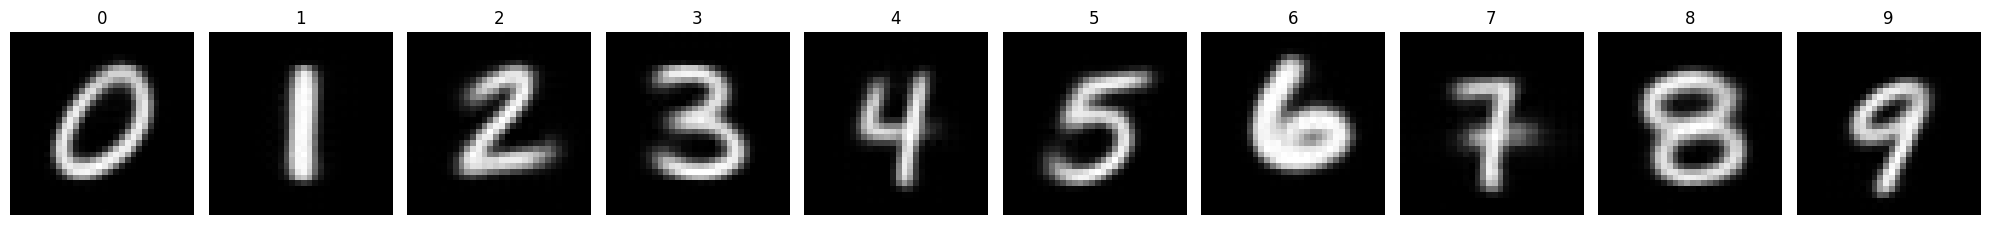

Epoch 74/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1237 - noise_loss: 0.0850 - kl_loss: 3.8663 - val_loss: 0.1230 - val_noise_loss: 0.0845 - val_image_loss: 0.0845 - val_kl_loss: 3.8486 - learning_rate: 1.5773e-04


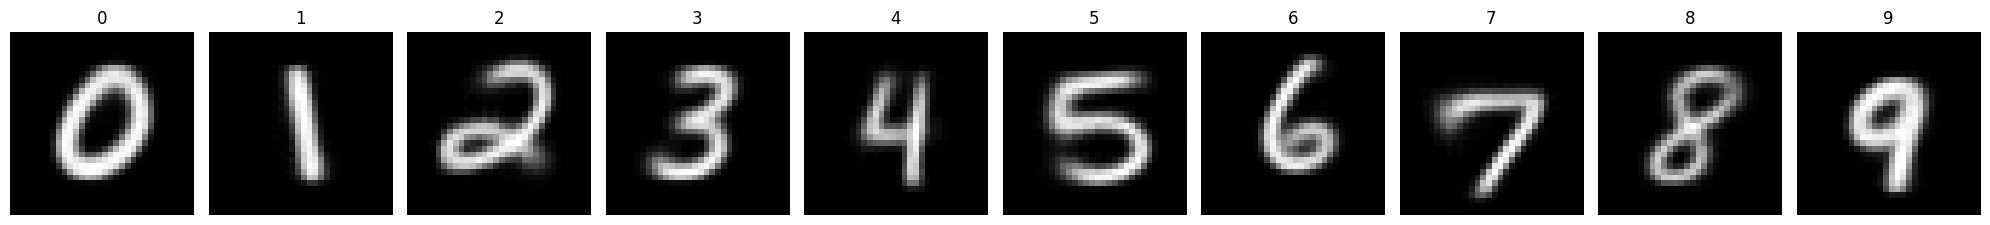

Epoch 75/100
468/468 [==============================] - 68s 146ms/step - loss: 0.1236 - noise_loss: 0.0849 - kl_loss: 3.8745 - val_loss: 0.1231 - val_noise_loss: 0.0846 - val_image_loss: 0.0846 - val_kl_loss: 3.8508 - learning_rate: 1.4645e-04


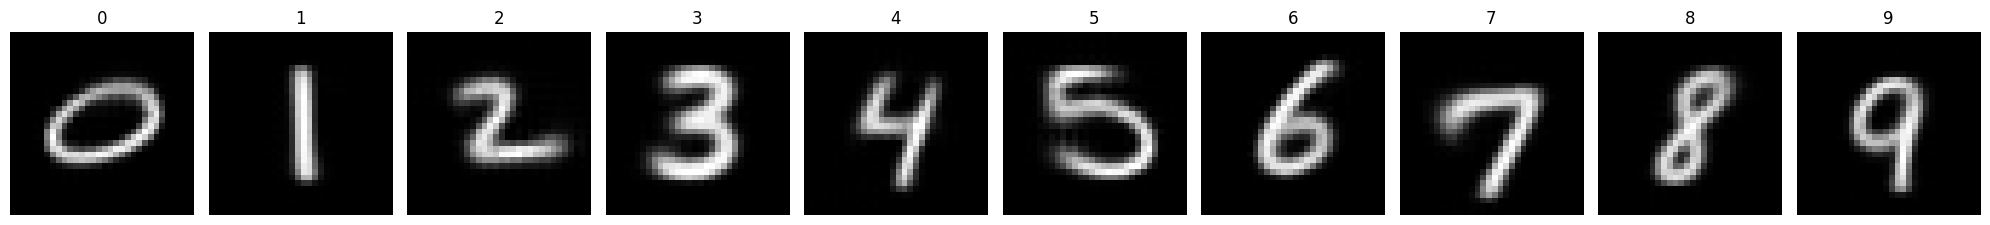

Epoch 76/100
468/468 [==============================] - 67s 143ms/step - loss: 0.1236 - noise_loss: 0.0848 - kl_loss: 3.8769 - val_loss: 0.1232 - val_noise_loss: 0.0846 - val_image_loss: 0.0846 - val_kl_loss: 3.8545 - learning_rate: 1.3552e-04


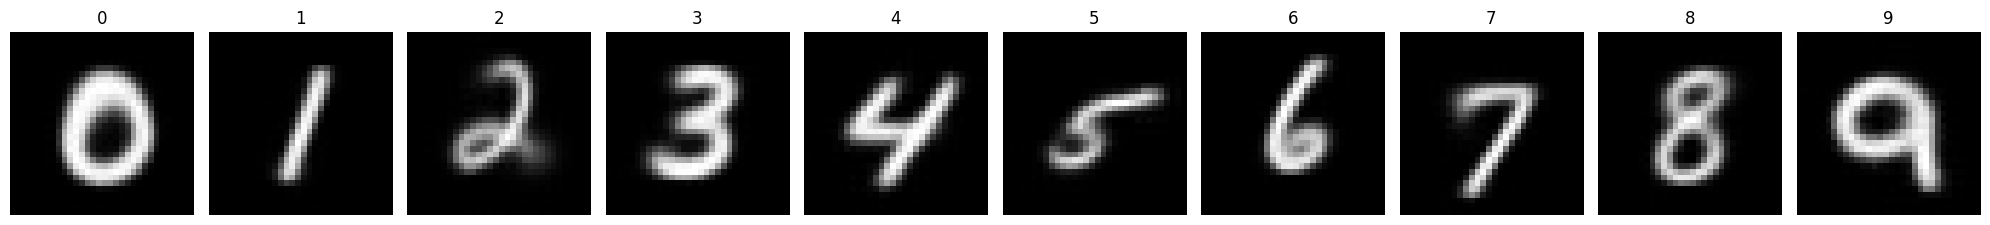

Epoch 77/100
468/468 [==============================] - 67s 144ms/step - loss: 0.1234 - noise_loss: 0.0847 - kl_loss: 3.8708 - val_loss: 0.1234 - val_noise_loss: 0.0848 - val_image_loss: 0.0848 - val_kl_loss: 3.8545 - learning_rate: 1.2494e-04


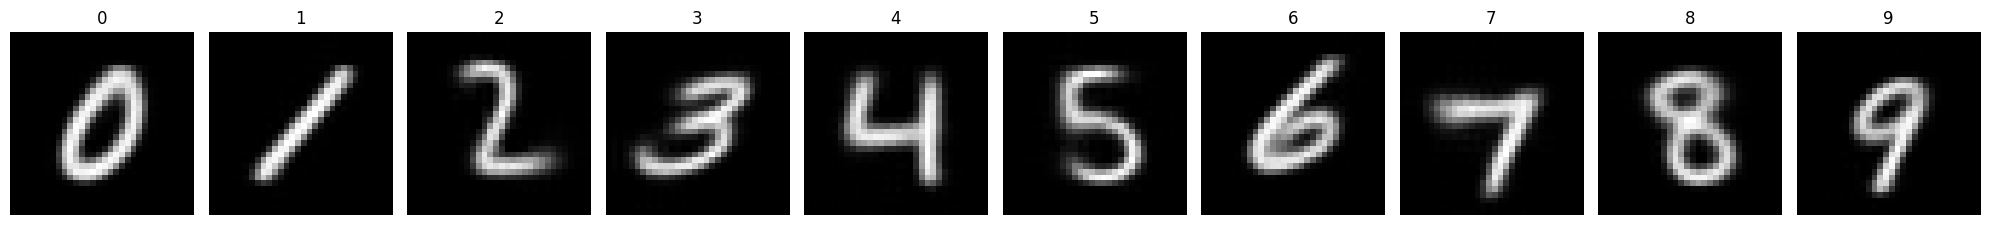

Epoch 78/100
468/468 [==============================] - 67s 144ms/step - loss: 0.1236 - noise_loss: 0.0847 - kl_loss: 3.8895 - val_loss: 0.1233 - val_noise_loss: 0.0847 - val_image_loss: 0.0847 - val_kl_loss: 3.8611 - learning_rate: 1.1474e-04


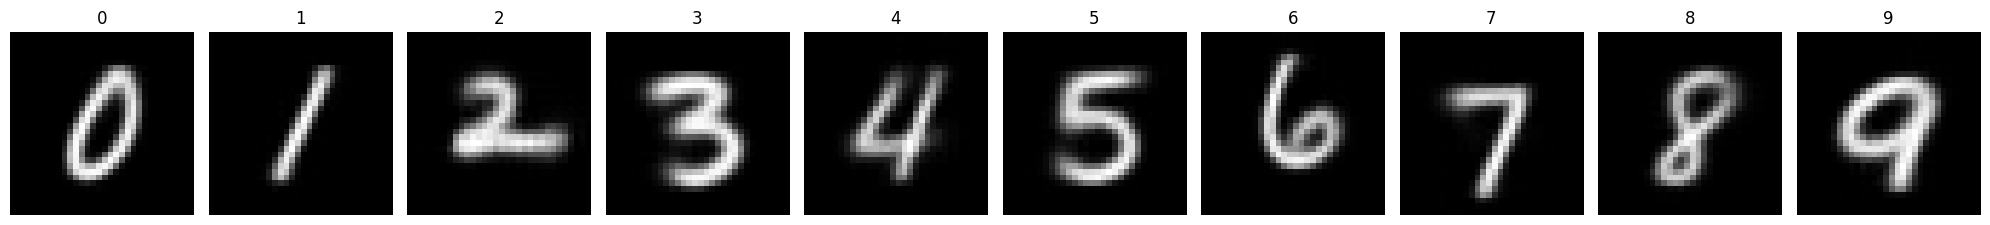

Epoch 79/100
468/468 [==============================] - 68s 144ms/step - loss: 0.1235 - noise_loss: 0.0845 - kl_loss: 3.8944 - val_loss: 0.1230 - val_noise_loss: 0.0844 - val_image_loss: 0.0844 - val_kl_loss: 3.8662 - learning_rate: 1.0492e-04


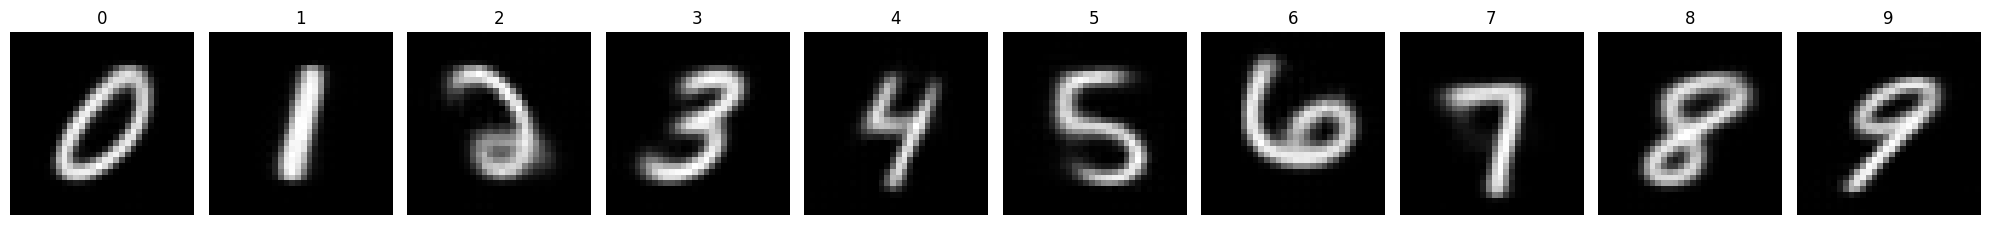

Epoch 80/100
468/468 [==============================] - 68s 146ms/step - loss: 0.1234 - noise_loss: 0.0844 - kl_loss: 3.8963 - val_loss: 0.1232 - val_noise_loss: 0.0845 - val_image_loss: 0.0845 - val_kl_loss: 3.8707 - learning_rate: 9.5491e-05


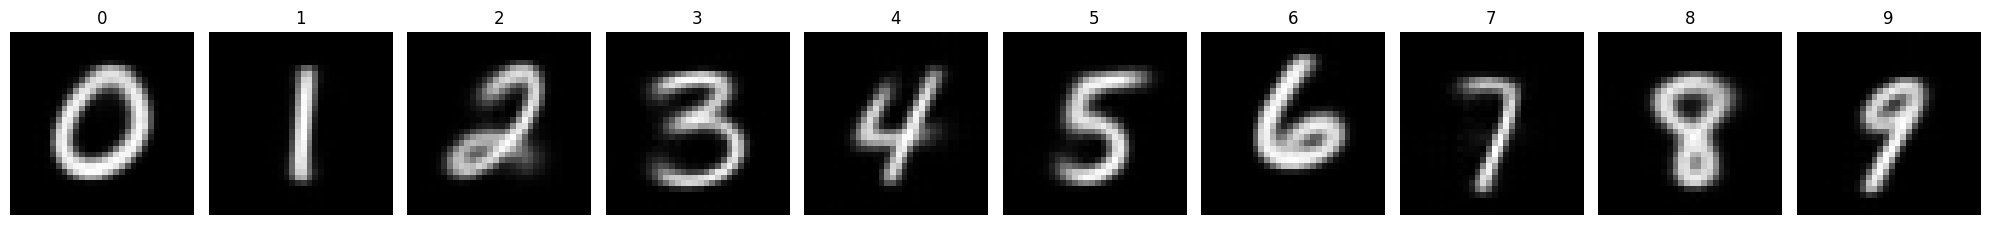

Epoch 81/100
468/468 [==============================] - 66s 141ms/step - loss: 0.1233 - noise_loss: 0.0844 - kl_loss: 3.8976 - val_loss: 0.1232 - val_noise_loss: 0.0845 - val_image_loss: 0.0845 - val_kl_loss: 3.8741 - learning_rate: 8.6460e-05


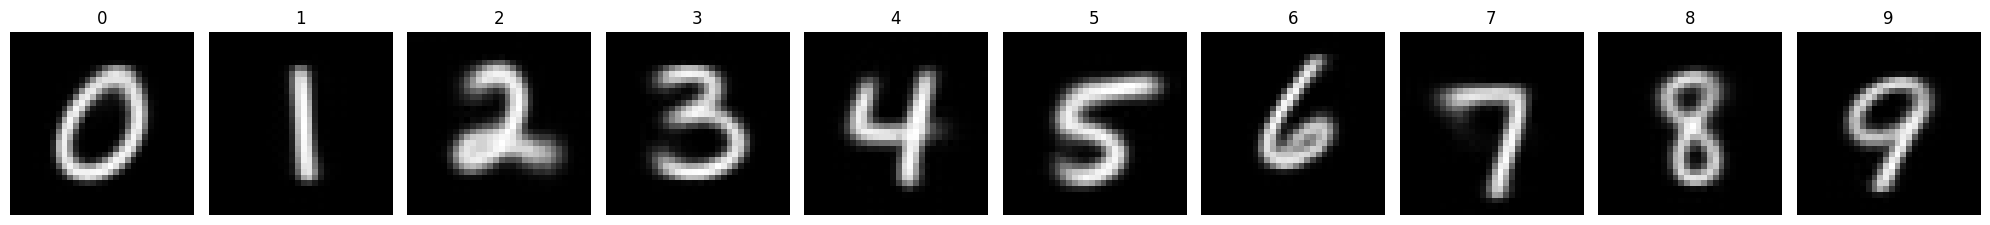

Epoch 82/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1233 - noise_loss: 0.0843 - kl_loss: 3.9008 - val_loss: 0.1231 - val_noise_loss: 0.0843 - val_image_loss: 0.0843 - val_kl_loss: 3.8765 - learning_rate: 7.7836e-05


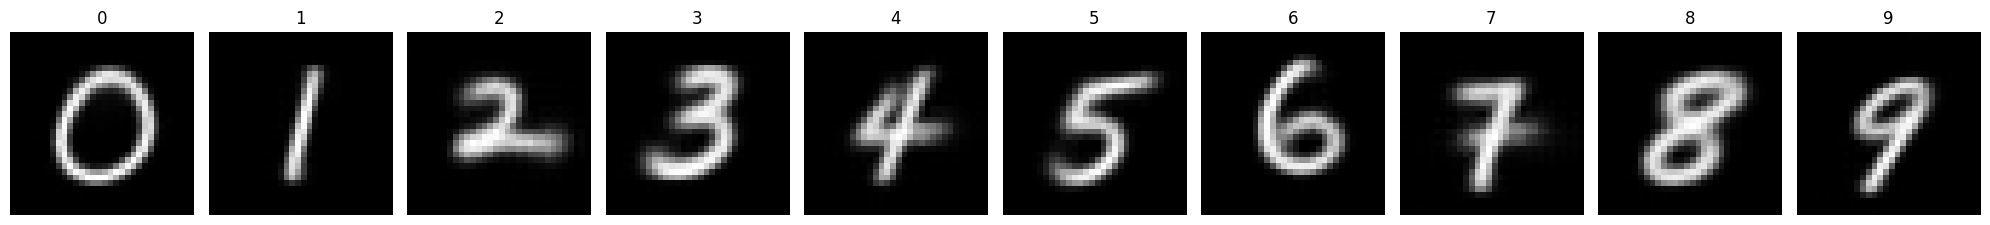

Epoch 83/100
468/468 [==============================] - 66s 141ms/step - loss: 0.1233 - noise_loss: 0.0842 - kl_loss: 3.9081 - val_loss: 0.1231 - val_noise_loss: 0.0843 - val_image_loss: 0.0843 - val_kl_loss: 3.8817 - learning_rate: 6.9629e-05


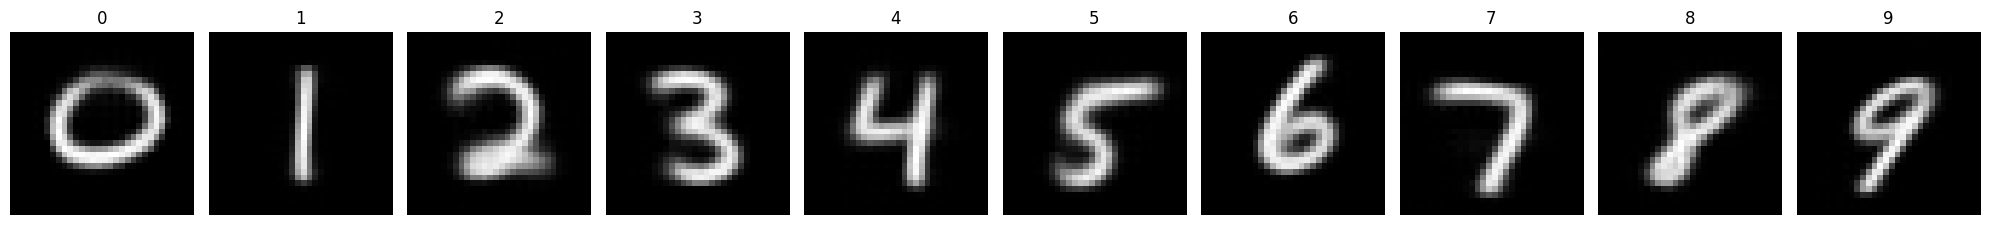

Epoch 84/100
468/468 [==============================] - 67s 144ms/step - loss: 0.1232 - noise_loss: 0.0842 - kl_loss: 3.9058 - val_loss: 0.1233 - val_noise_loss: 0.0844 - val_image_loss: 0.0844 - val_kl_loss: 3.8838 - learning_rate: 6.1847e-05


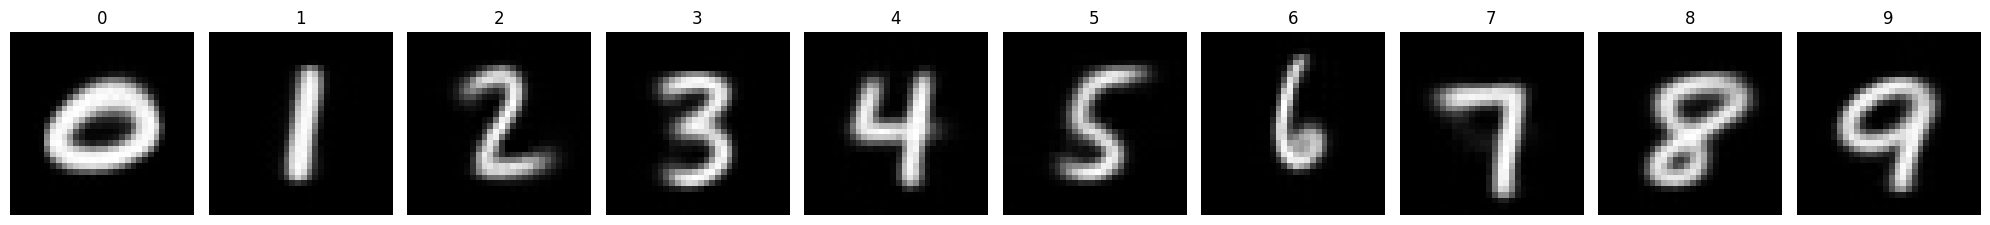

Epoch 85/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1232 - noise_loss: 0.0841 - kl_loss: 3.9053 - val_loss: 0.1232 - val_noise_loss: 0.0844 - val_image_loss: 0.0844 - val_kl_loss: 3.8845 - learning_rate: 5.4497e-05


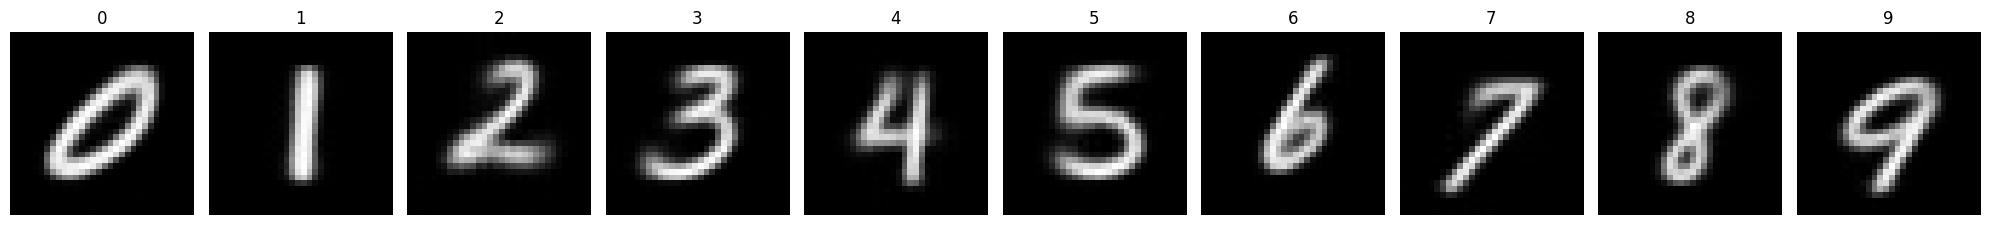

Epoch 86/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1233 - noise_loss: 0.0842 - kl_loss: 3.9091 - val_loss: 0.1230 - val_noise_loss: 0.0841 - val_image_loss: 0.0841 - val_kl_loss: 3.8859 - learning_rate: 4.7586e-05


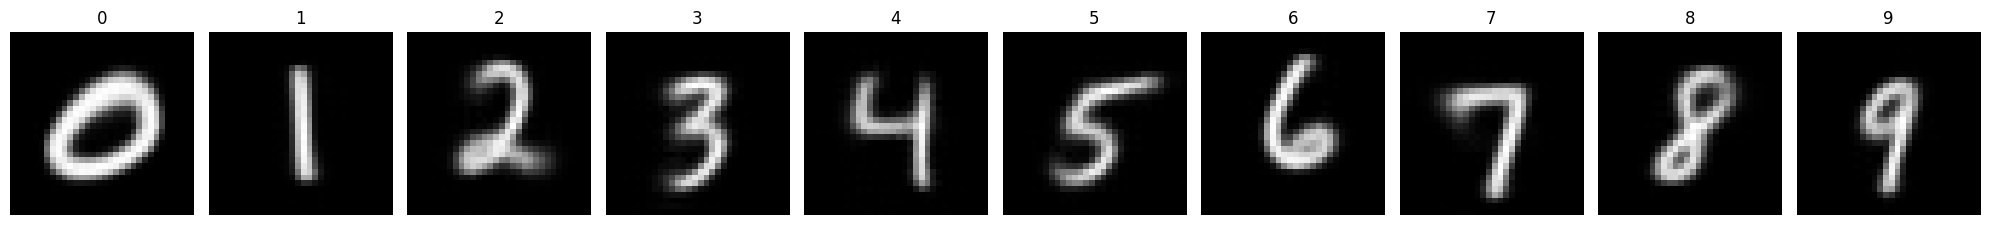

Epoch 87/100
468/468 [==============================] - 65s 139ms/step - loss: 0.1230 - noise_loss: 0.0839 - kl_loss: 3.9098 - val_loss: 0.1232 - val_noise_loss: 0.0844 - val_image_loss: 0.0844 - val_kl_loss: 3.8878 - learning_rate: 4.1123e-05


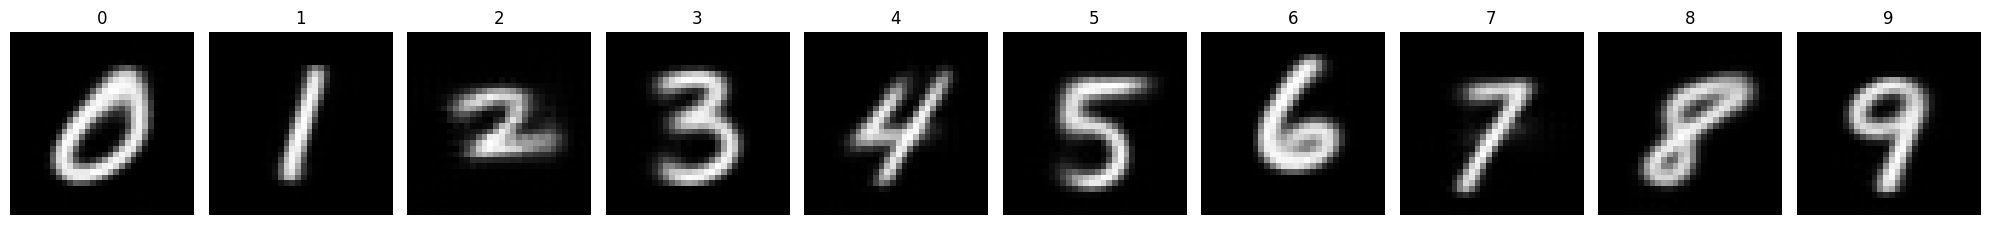

Epoch 88/100
468/468 [==============================] - 68s 146ms/step - loss: 0.1231 - noise_loss: 0.0839 - kl_loss: 3.9173 - val_loss: 0.1229 - val_noise_loss: 0.0840 - val_image_loss: 0.0840 - val_kl_loss: 3.8914 - learning_rate: 3.5112e-05


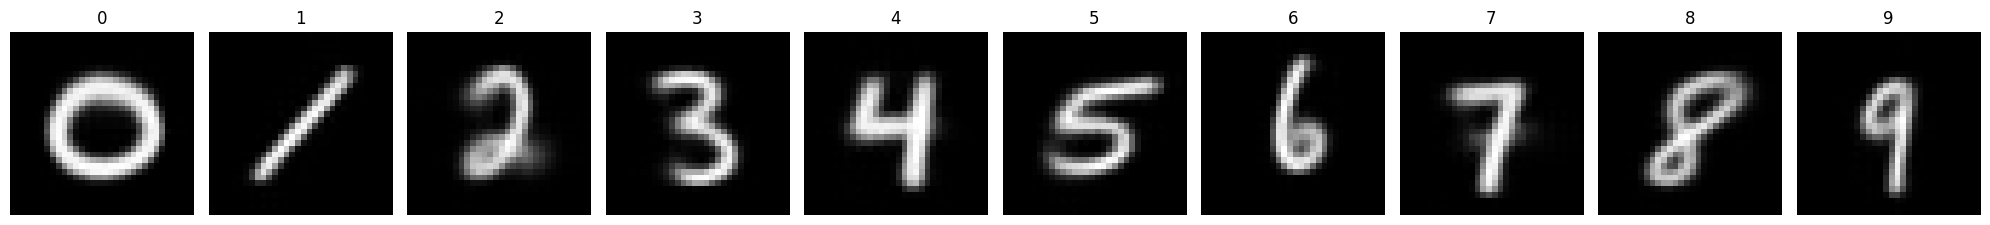

Epoch 89/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1231 - noise_loss: 0.0840 - kl_loss: 3.9135 - val_loss: 0.1230 - val_noise_loss: 0.0841 - val_image_loss: 0.0841 - val_kl_loss: 3.8926 - learning_rate: 2.9560e-05


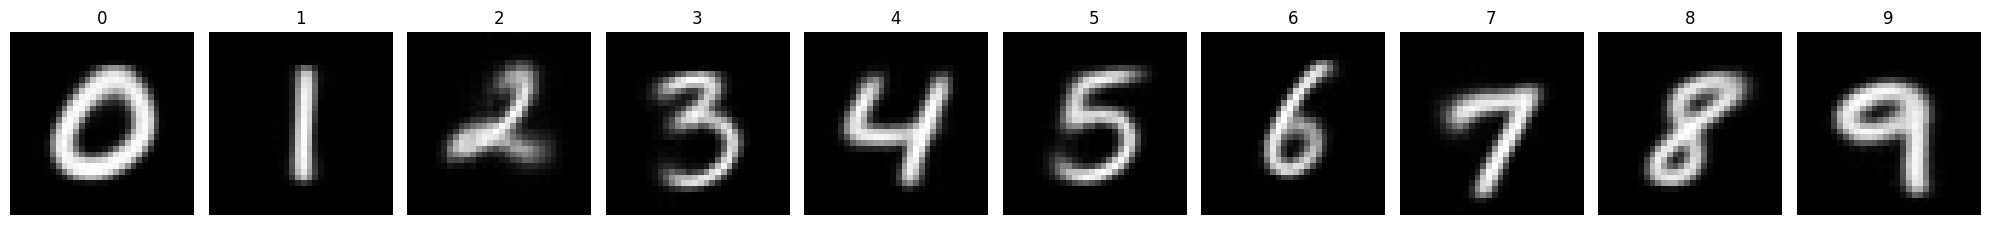

Epoch 90/100
468/468 [==============================] - 66s 141ms/step - loss: 0.1230 - noise_loss: 0.0838 - kl_loss: 3.9164 - val_loss: 0.1230 - val_noise_loss: 0.0841 - val_image_loss: 0.0841 - val_kl_loss: 3.8935 - learning_rate: 2.4472e-05


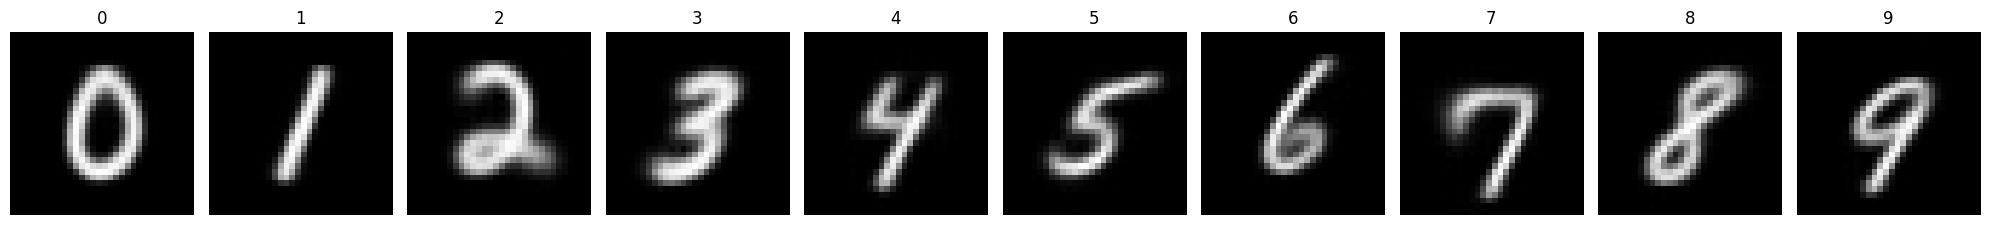

Epoch 91/100
468/468 [==============================] - 65s 140ms/step - loss: 0.1230 - noise_loss: 0.0838 - kl_loss: 3.9151 - val_loss: 0.1230 - val_noise_loss: 0.0840 - val_image_loss: 0.0840 - val_kl_loss: 3.8938 - learning_rate: 1.9853e-05


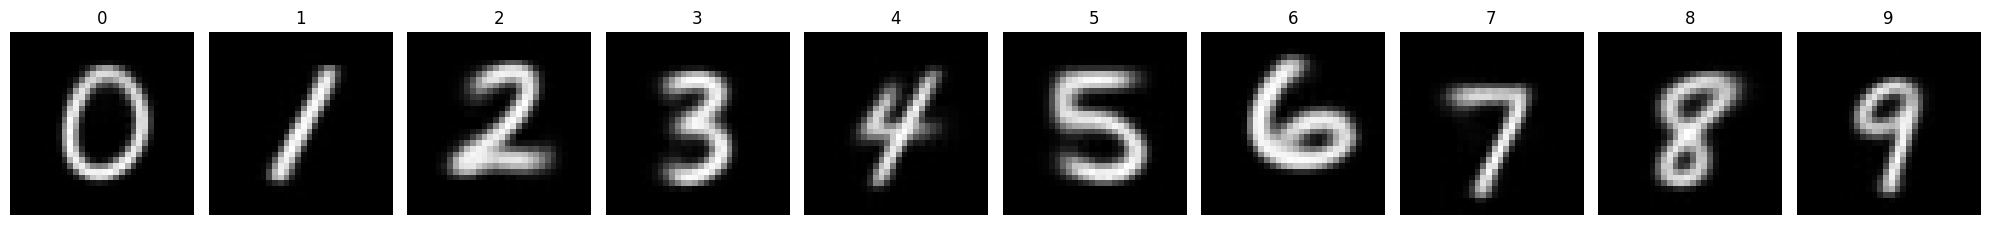

Epoch 92/100
468/468 [==============================] - 68s 144ms/step - loss: 0.1230 - noise_loss: 0.0838 - kl_loss: 3.9177 - val_loss: 0.1229 - val_noise_loss: 0.0840 - val_image_loss: 0.0840 - val_kl_loss: 3.8948 - learning_rate: 1.5708e-05


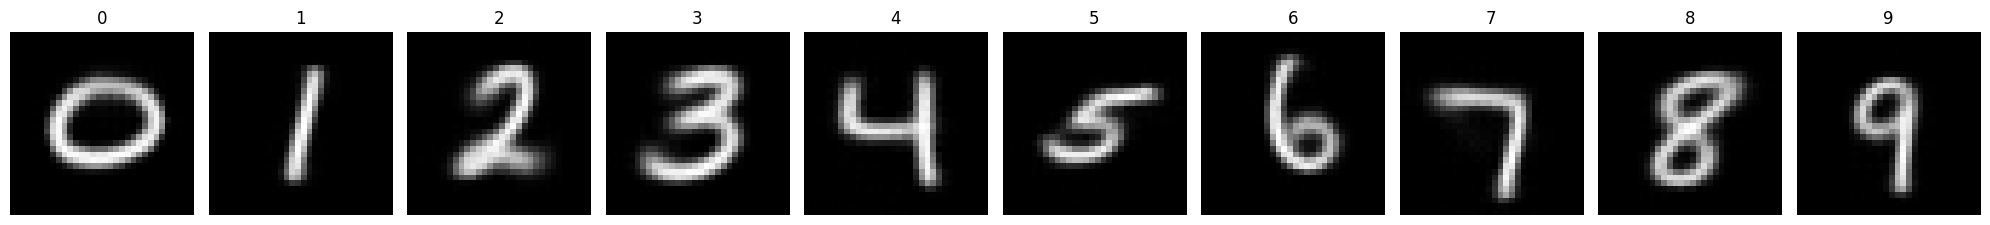

Epoch 93/100
468/468 [==============================] - 65s 139ms/step - loss: 0.1229 - noise_loss: 0.0837 - kl_loss: 3.9199 - val_loss: 0.1232 - val_noise_loss: 0.0842 - val_image_loss: 0.0842 - val_kl_loss: 3.8959 - learning_rate: 1.2042e-05


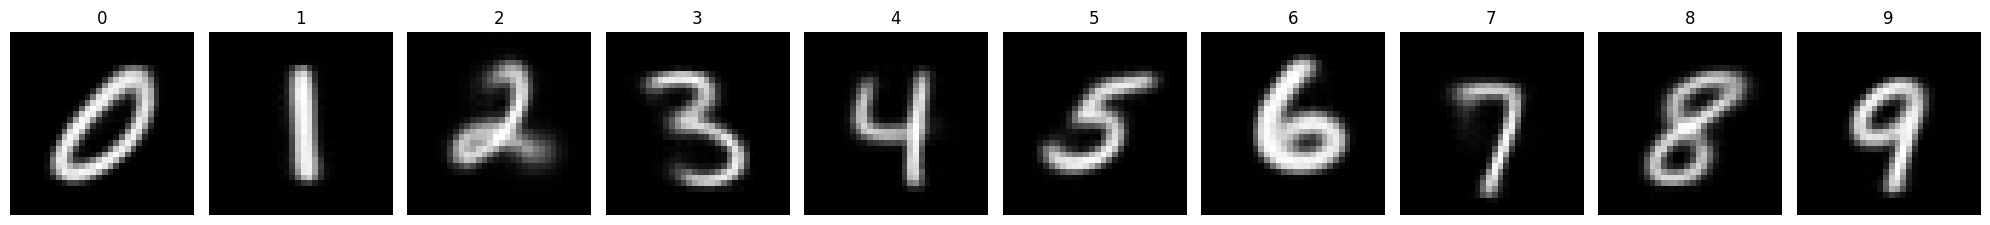

Epoch 94/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1229 - noise_loss: 0.0837 - kl_loss: 3.9220 - val_loss: 0.1231 - val_noise_loss: 0.0841 - val_image_loss: 0.0841 - val_kl_loss: 3.8977 - learning_rate: 8.8564e-06


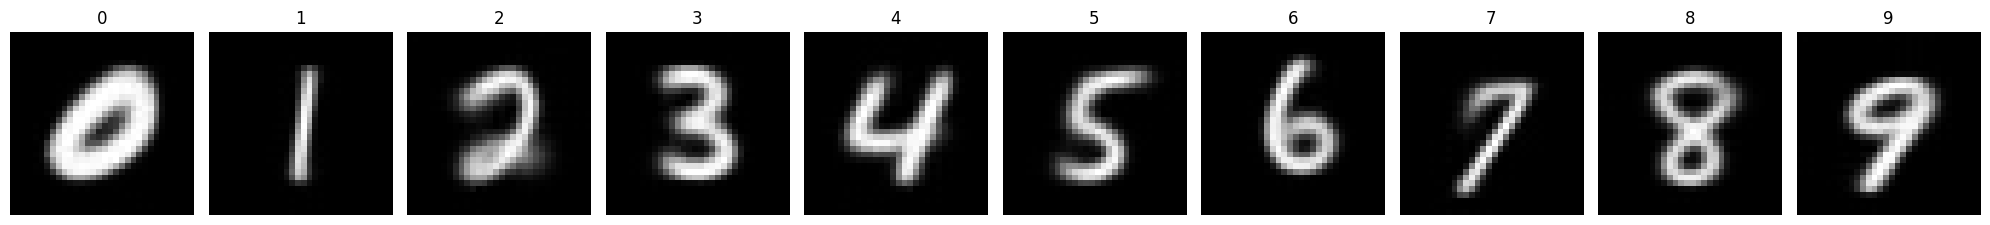

Epoch 95/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1229 - noise_loss: 0.0837 - kl_loss: 3.9192 - val_loss: 0.1229 - val_noise_loss: 0.0839 - val_image_loss: 0.0839 - val_kl_loss: 3.8973 - learning_rate: 6.1558e-06


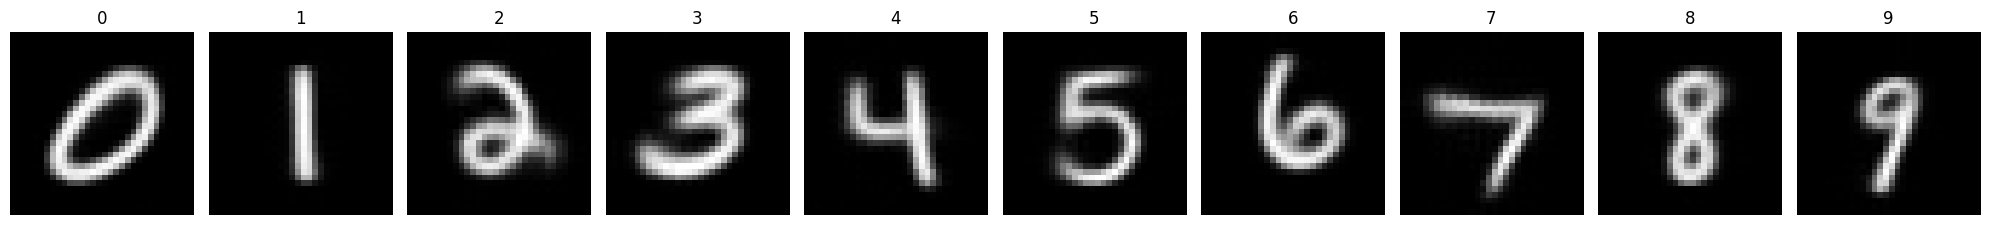

Epoch 96/100
468/468 [==============================] - 65s 140ms/step - loss: 0.1230 - noise_loss: 0.0837 - kl_loss: 3.9279 - val_loss: 0.1230 - val_noise_loss: 0.0840 - val_image_loss: 0.0840 - val_kl_loss: 3.9006 - learning_rate: 3.9426e-06


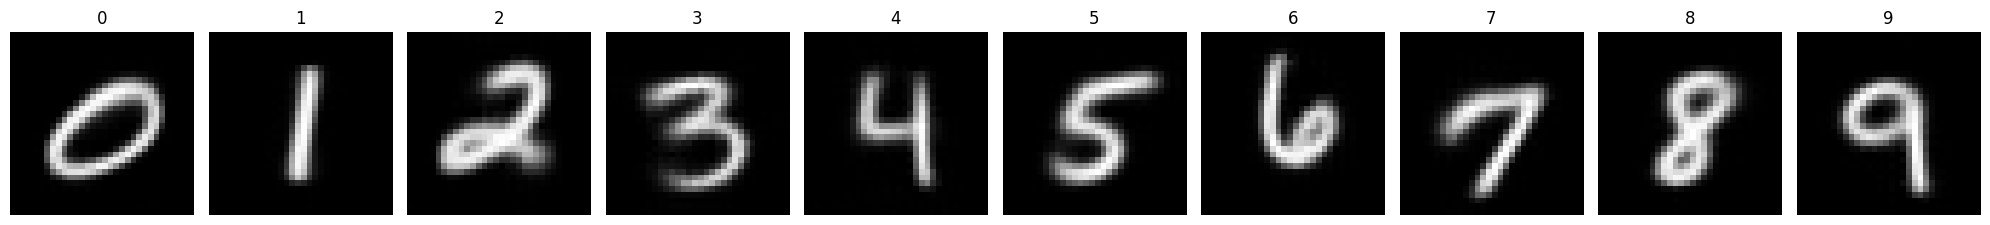

Epoch 97/100
468/468 [==============================] - 65s 140ms/step - loss: 0.1229 - noise_loss: 0.0836 - kl_loss: 3.9273 - val_loss: 0.1230 - val_noise_loss: 0.0840 - val_image_loss: 0.0840 - val_kl_loss: 3.9024 - learning_rate: 2.2190e-06


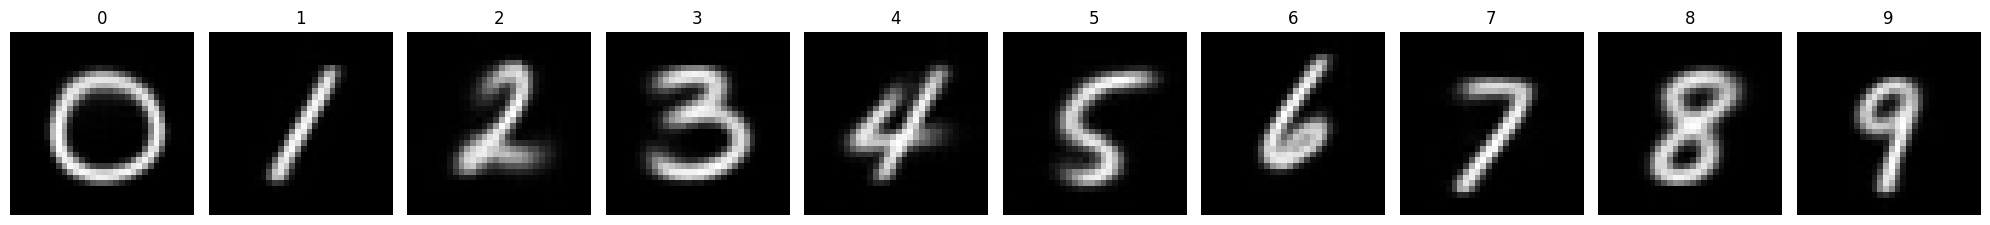

Epoch 98/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1231 - noise_loss: 0.0838 - kl_loss: 3.9285 - val_loss: 0.1231 - val_noise_loss: 0.0841 - val_image_loss: 0.0841 - val_kl_loss: 3.9041 - learning_rate: 9.8664e-07


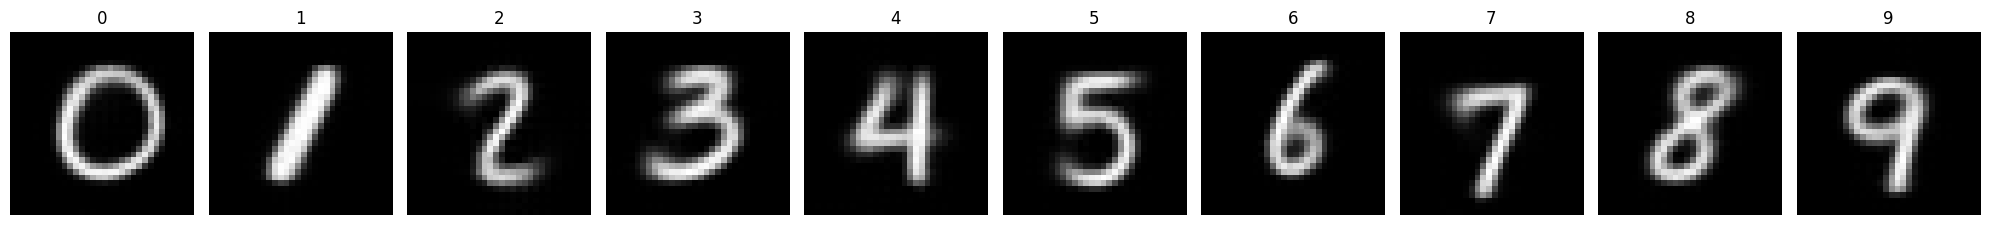

Epoch 99/100
468/468 [==============================] - 67s 143ms/step - loss: 0.1229 - noise_loss: 0.0836 - kl_loss: 3.9282 - val_loss: 0.1230 - val_noise_loss: 0.0839 - val_image_loss: 0.0839 - val_kl_loss: 3.9049 - learning_rate: 2.4673e-07


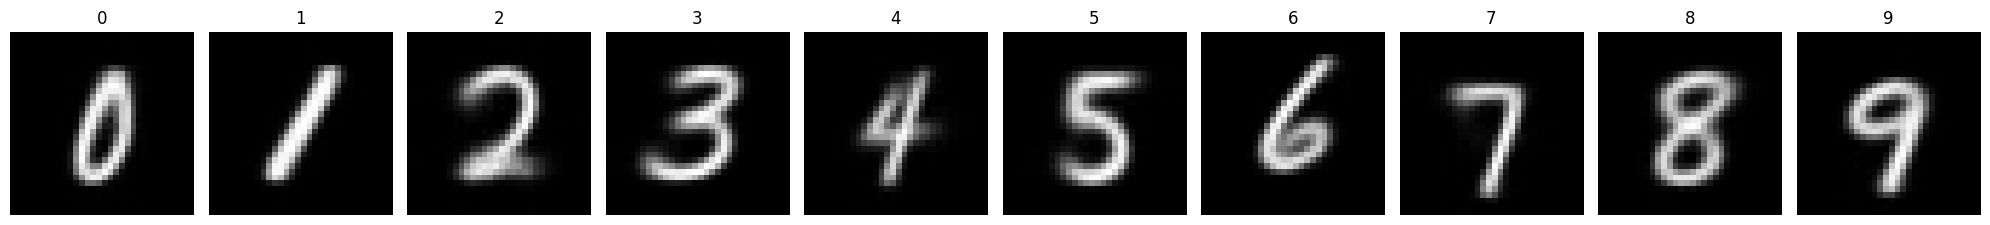

Epoch 100/100
468/468 [==============================] - 67s 144ms/step - loss: 0.1229 - noise_loss: 0.0837 - kl_loss: 3.9261 - val_loss: 0.1234 - val_noise_loss: 0.0844 - val_image_loss: 0.0844 - val_kl_loss: 3.9048 - learning_rate: 0.0000e+00


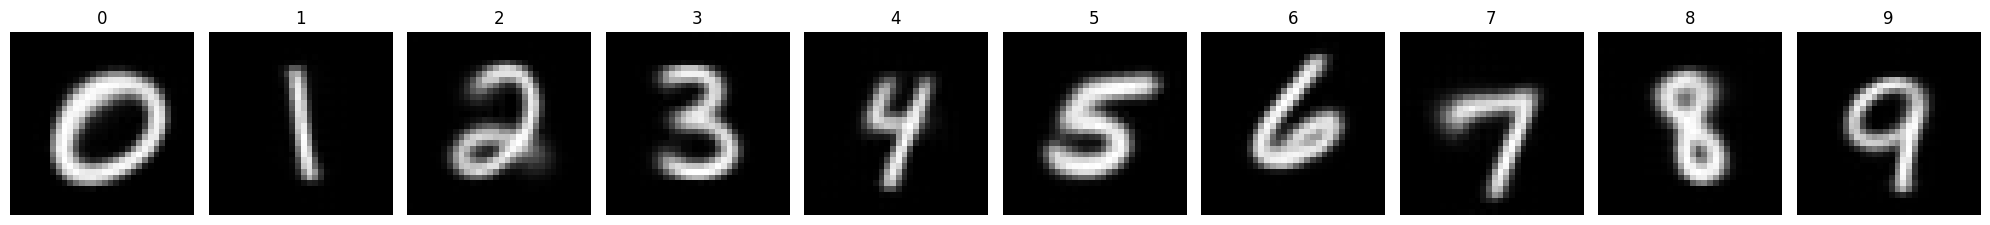

In [8]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list
).history

In [ ]:
model.save_weights("./models/VAE U-DiT/model.weights.h5")

In [10]:
model.evaluate(valset, network_name="ema")

79/79 [==============================] - 8s 71ms/step - loss: 0.1231 - noise_loss: 0.0841 - image_loss: 0.0841 - kl_loss: 3.9048


[0.12314523011445999,
 0.08409762382507324,
 0.08409762382507324,
 3.9047601222991943]

In [11]:
model.evaluate(valset, network_name="raw")

79/79 [==============================] - 8s 70ms/step - loss: 0.1233 - noise_loss: 0.0843 - image_loss: 0.0843 - kl_loss: 3.9043


[0.12334538251161575,
 0.08430233597755432,
 0.08430233597755432,
 3.9043028354644775]

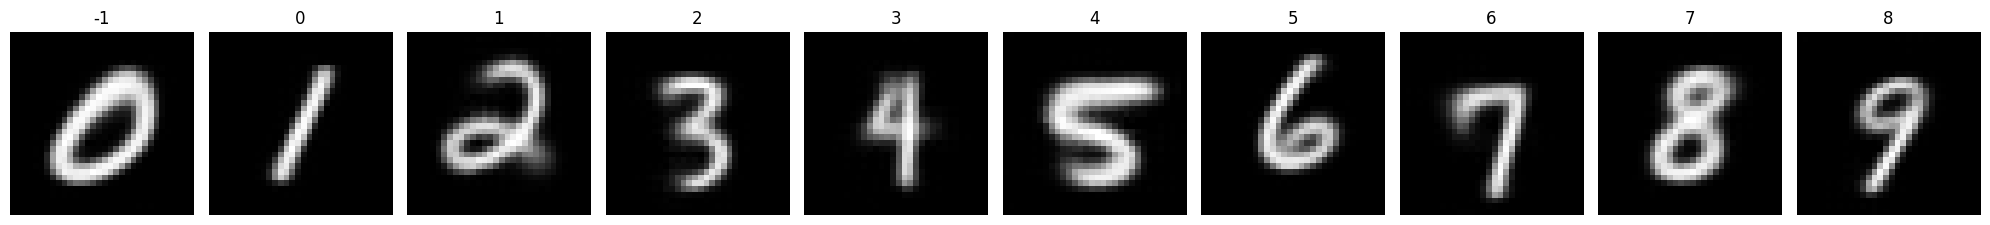

In [12]:
from common.utils import plot_images


imgs = model.sample_vae(add_null_label=True)
plot_images(imgs, has_null_label=True)

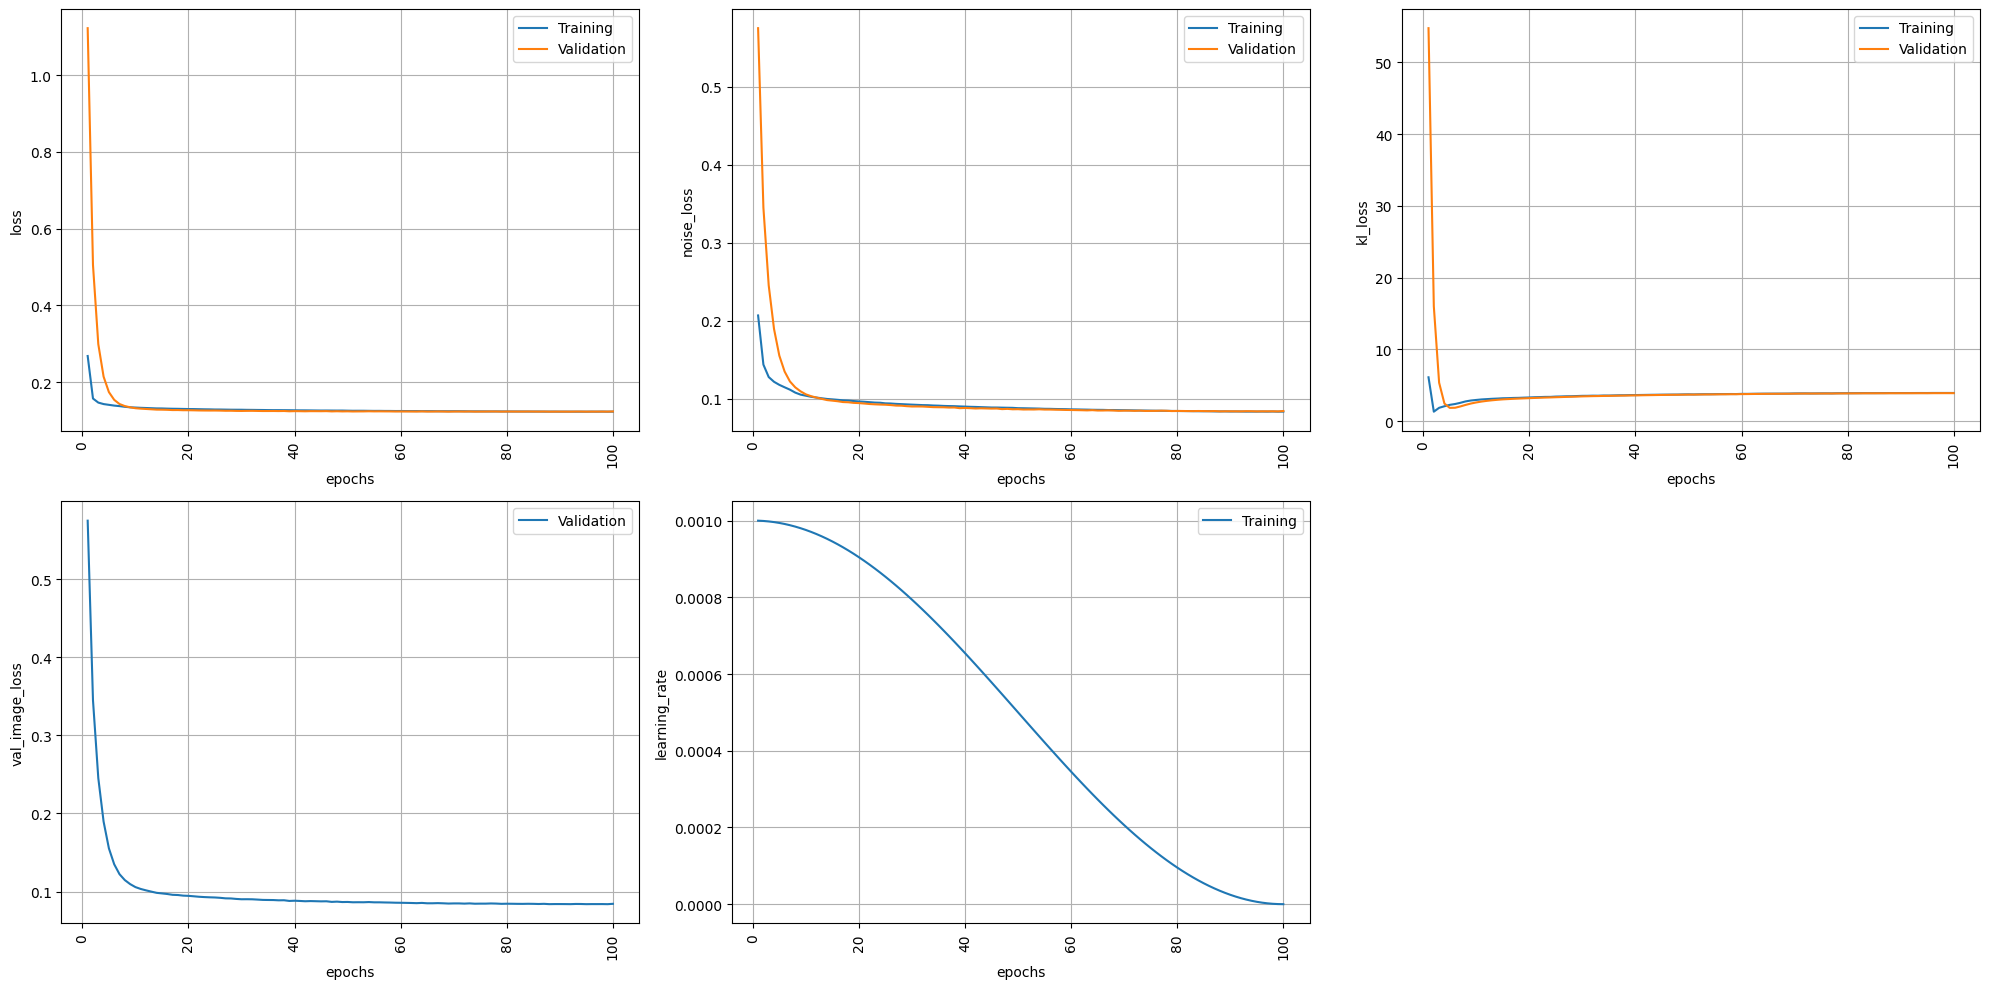

In [13]:
from common.utils import plot_history


plot_history(history)

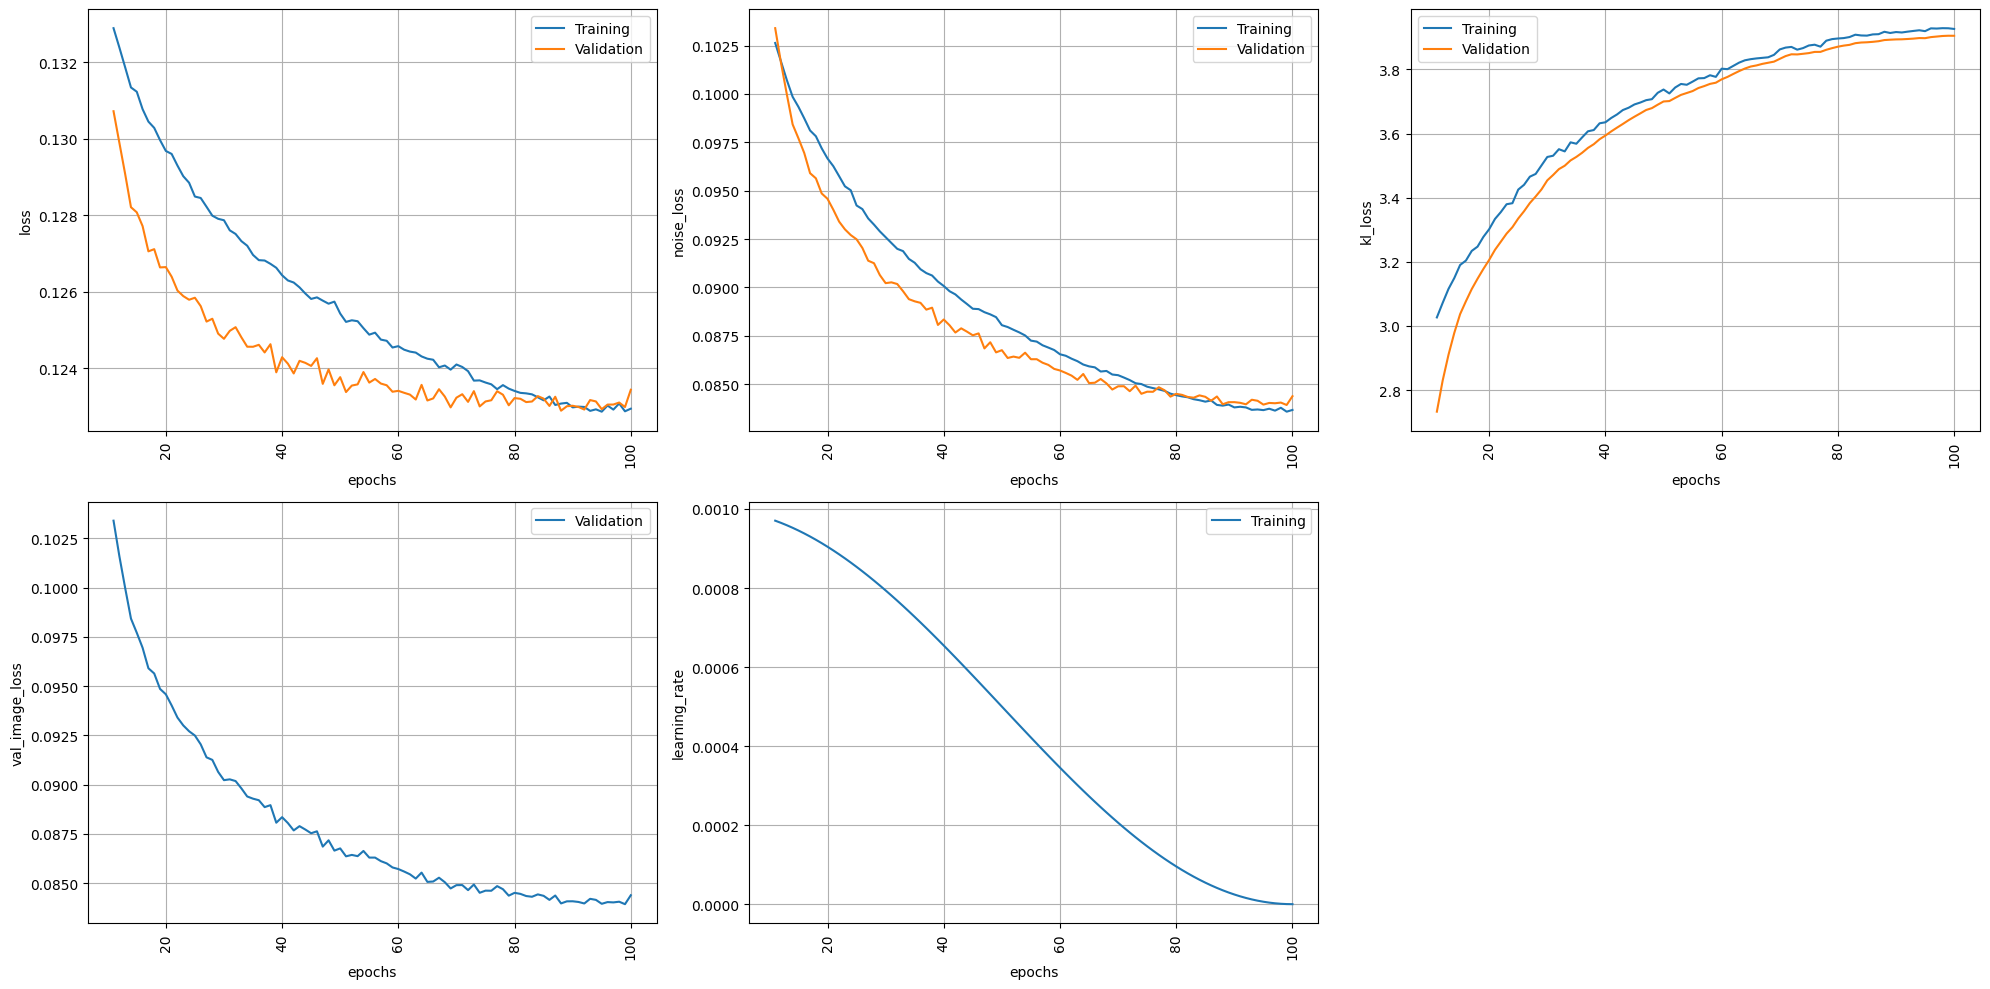

In [14]:
plot_history(history, show_all_x_ticks=False, range_=(10, None))